# 📏 Notebook 05 — Production Baseline Model Benchmarking

<div style='background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 20px; border-radius: 10px; color: white; margin: 10px 0;'>

**Baseline Benchmarking Suite** — Trains and evaluates 8 baseline models on chronologically split feature store data.

</div>

| Property | Value |
|:---|:---|
| 🏗️ **Target** | `unit_sales` (log-transformed $\log(1 + y)$ during model fitting) |
| 📥 **Input** | `feature_store.parquet` via partial row-group loader (`utils.load_feature_store_partial`) |
| 📅 **Split Strategy** | Chronological Out-of-Time Split (Train: 2015-04 to 2017-07 \| Val: 2017-08) |
| 📊 **Evaluation Metrics** | RMSLE (Primary), RMSE, MAE, MAPE, $R^2$, Training Time, Inference Time |
| 🖼️ **Plots Directory** | `output/05_baseline_models/plots/` |
| 🤖 **Models Evaluated** | Global Mean, Global Median, Seasonal Naive, OLS, Ridge, Lasso, ElasticNet, Random Forest |

---

### 📑 Table of Contents

| # | Section | Purpose |
|:---:|:---|:---| 
| 1 | Environment Setup | Bootstrap project paths |
| 2 | Imports & Setup | Load packages, set random seeds, output configuration |
| 3 | Load Feature Store | Load 1M row partial feature store subset via PyArrow |
| 4 | Data Quality Audit | Inspect missing values, infinities, and column types |
| 5 | Feature Detection | Automatic feature identification & leakage prevention |
| 6 | Chronological Split | Out-of-Time Train / Validation split with visual timeline |
| 7 | Feature Scaling | StandardScaler fitting on train set only |
| 8 | Evaluation Engine | Standardized metric calculation and logging functions |
| 9 | Model Training | Train 8 baseline models & analyze linear coefficients |
| 10 | Master Leaderboard | Ranked benchmark comparison table & JSON export |
| 11 | Visualization Suite | Comprehensive model comparison charts & overlays |
| 12 | Executive Dashboard | Key insights and model recommendations |
| 13 | Final Cleanup | Memory release and execution summary |


---
## 1️⃣ Environment Setup & Project Bootstrap

> Adds project root to `sys.path` for module loading.


In [1]:
# ============================================================
# 1. Environment Bootstrap (Colab + Local)
# ============================================================
import os, sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

POSSIBLE_ROOTS = [
    Path('/content/drive/MyDrive/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/NTI/Demand-Forecasting-System'),
    Path('/content/drive/MyDrive/Colab Notebooks/Demand-Forecasting-System'),
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_ROOT = None
for p in POSSIBLE_ROOTS:
    if p.exists() and (p / 'config.py').exists():
        PROJECT_ROOT = p.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        '❌ Project root with config.py not found.\n'
        'Colab: Make sure the folder is in your Google Drive.\n'
        'Local: Run the notebook from inside the project directory.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

ENV = 'Google Colab' if 'google.colab' in sys.modules else 'Local'
print('=' * 60)
print(f'📁 Project Root : {PROJECT_ROOT}')
print(f'📂 Working Dir  : {os.getcwd()}')
print(f'🖥️  Runtime      : {ENV}')
print('✅ Bootstrap OK')
print('=' * 60)


📁 Project Root : F:\NTI\Demand Forecasting System Backup
📂 Working Dir  : F:\NTI\Demand Forecasting System Backup
🖥️  Runtime      : Local
✅ Bootstrap OK


---
## 2️⃣ Imports, Configuration & Output Directory Setup

> Import scientific stack and project infrastructure.


In [2]:
# ============================================================
# 2. System Imports, Configuration & Output Directories
# ============================================================
import os, sys, time, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import config, utils
# Linear Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
)

# Tree Models
from sklearn.tree import DecisionTreeRegressor

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)

# Neighbors
from sklearn.neighbors import KNeighborsRegressor

# Support Vector Machine
from sklearn.svm import SVR
NOTEBOOK_START = time.time()

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Central Output Directory for NB05
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '05_baseline_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Central Model Registry Directory (03_Models/)
MODELS_DIR = Path(getattr(config, 'MODELS_DIR', Path(config.PROJECT_ROOT) / '03_Models')) / 'baseline_models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Plots Directory inside NB05 output
PLOTS_DIR = OUTPUT_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename):
    """Save figure artifact to PLOTS_DIR."""

    filepath = PLOTS_DIR / filename

    # Create directory automatically
    filepath.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        filepath,
        dpi=200,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

    print(f'💾 Saved plot → {filepath}')

print(f'📁 Output Directory  : {OUTPUT_DIR}')
print(f'🤖 Models Directory  : {MODELS_DIR}')
print(f'🖼️ Plots Directory   : {PLOTS_DIR}')
utils.memory_checkpoint('After Environment Setup')

# Alias for memory checkpointing
log_ram = utils.memory_checkpoint


📁 Output Directory  : F:\NTI\Demand Forecasting System Backup\output\05_baseline_models
🤖 Models Directory  : F:\NTI\Demand Forecasting System Backup\03_Models\baseline_models
🖼️ Plots Directory   : F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots
[2026-07-29 22:40:10] [INFO] 🧠 RAM Checkpoint [After Environment Setup]: 0.24 GB


---
## 3️⃣ Load Feature Store Subset

> Load recent 1,000,000 observations using `utils.load_feature_store_partial()`.


⏳ Loading Feature Store subset...
[2026-07-29 22:40:14] [INFO] ⚡ [Fast Partial Loader] Rows: 5,000,000 | Cols: 74 | RAM: 2.80 GB | Time: 1.53s
[2026-07-29 22:40:16] [INFO] 🧠 RAM Checkpoint [After Partial Load]: 4.34 GB

🔍 Validating Loaded Dataset...
✓ Validation Complete

📊 BASELINE DATASET SUMMARY
Rows Loaded          :       5,000,000
Number of Columns    : 74
Memory Usage         : 2.80 GB
Date Range           : 2013-04-01 00:00:00 → 2017-08-15 00:00:00
Unique Dates         : 1,590
Load Time            : 3.58 sec


,Metric,Value
0,Rows,"5,000,000"
1,Columns,74
2,Missing Values,"74,882"
3,Infinite Values,0
4,Duplicate Rows,0
5,Memory (GB),2.80



🎯 Target Statistics


,count,mean,std,min,25%,50%,75%,max
unit_sales,5000000.0000,7.9732,15.4042,0.0000,2.0000,4.0000,8.0000,212.7619


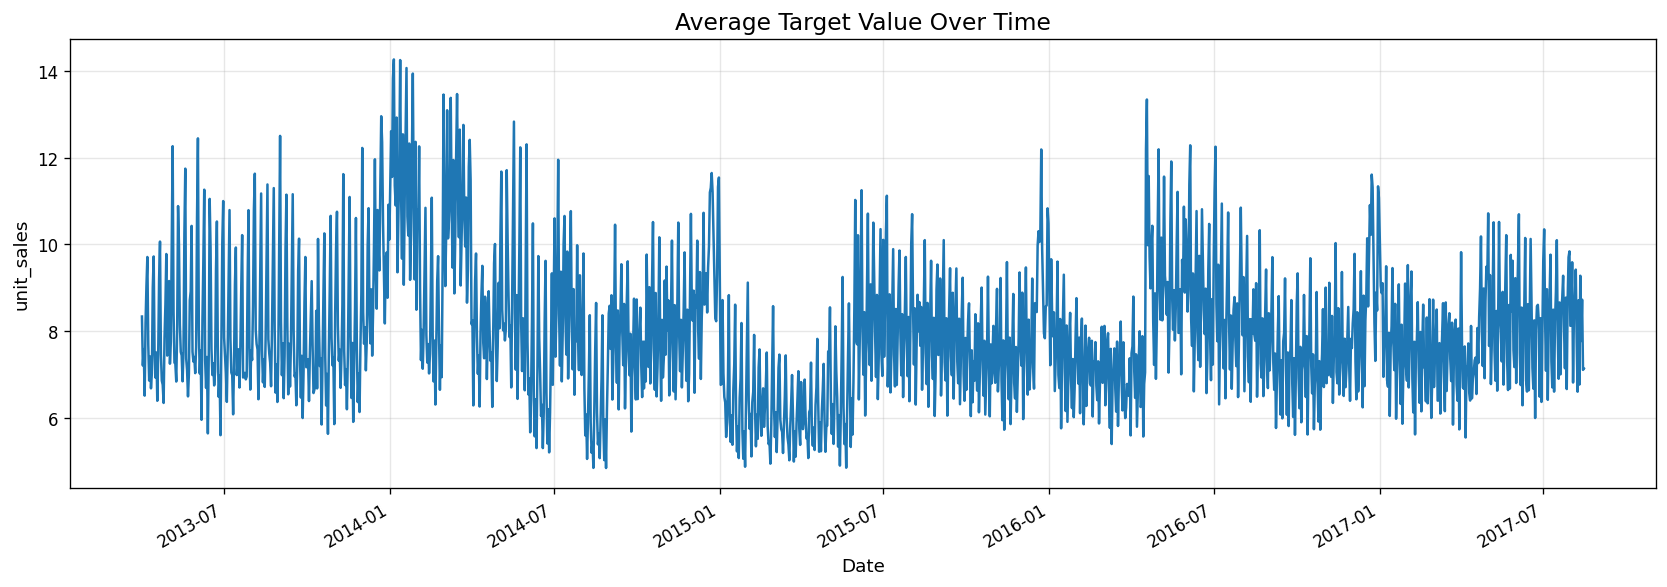

In [3]:
# ============================================================
# 3. Load Baseline Dataset
# ============================================================

# Number of most recent observations used for baseline experiments.
# We intentionally use the latest chronological data instead of random
# sampling to preserve the temporal nature of the forecasting problem.

BASELINE_ROWS = 5_000_000  # Adjust according to available RAM
TARGET = "unit_sales"
print("⏳ Loading Feature Store subset...")

t0 = time.time()

df = utils.load_feature_store_partial(
    rows=BASELINE_ROWS,
    newest=True,
    verbose=True,
)

load_time = time.time() - t0

df = df.reset_index(drop=True)

subset_rows = len(df)
subset_cols = len(df.columns)
subset_mem = df.memory_usage(deep=True).sum() / 1024**3

utils.memory_checkpoint("After Partial Load")

# ============================================================
# Dataset Validation
# ============================================================

print("\n🔍 Validating Loaded Dataset...")

numeric_df = df.select_dtypes(include=np.number)

missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()
infinite_values = np.isinf(numeric_df).sum().sum()

print("✓ Validation Complete")

# ============================================================
# Dataset Summary
# ============================================================

print("\n" + "=" * 70)
print("📊 BASELINE DATASET SUMMARY")
print("=" * 70)

print(f"Rows Loaded          : {subset_rows:>15,}")
print(f"Number of Columns    : {subset_cols}")
print(f"Memory Usage         : {subset_mem:.2f} GB")
print(f"Date Range           : {df['date'].min()} → {df['date'].max()}")
print(f"Unique Dates         : {df['date'].nunique():,}")
print(f"Load Time            : {load_time:.2f} sec")

print("=" * 70)

# ============================================================
# Data Quality Report
# ============================================================

quality_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Infinite Values",
        "Duplicate Rows",
        "Memory (GB)"
    ],
    "Value": [
        f"{subset_rows:,}",
        subset_cols,
        f"{missing_values:,}",
        f"{infinite_values:,}",
        f"{duplicate_rows:,}",
        f"{subset_mem:.2f}"
    ]
})

display(quality_report)

# ============================================================
# Target Statistics
# ============================================================

print("\n🎯 Target Statistics")

display(df[TARGET].describe().to_frame().T)

# ============================================================
# Quick Time-Series Check
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

(
    df.groupby("date")[TARGET]
      .mean()
      .plot(ax=ax)
)

ax.set_title("Average Target Value Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel(TARGET)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4️⃣ Data Validation & Quality Audit

> Audit missing values, infinite floats, and duplicate rows.


In [4]:
# ============================================================
# 4. Data Validation & Quality Audit
# ============================================================
TARGET_COL = 'unit_sales'

print(f'{"=" * 70}')
print('🔍 DATA VALIDATION REPORT')
print(f'{"=" * 70}')

# Shape
print(f'\n📐 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Missing Values
missing = df.isnull().sum()
n_missing_cols = (missing > 0).sum()
print(f'\n🔍 Missing Values:')
if n_missing_cols > 0:
    print(f'   ⚠️ {n_missing_cols} columns contain missing values')
    print(missing[missing > 0].to_string())
else:
    print(f'   ✅ No missing values detected')

# Infinite Values
num_df = df.select_dtypes(include=[np.number])
inf_count = np.isinf(num_df).sum().sum()
print(f'\n🔍 Infinite Values: {"⚠️ " + str(inf_count) + " found" if inf_count > 0 else "✅ None"}')

# Duplicate Rows
dup_count = df.duplicated().sum()
print(f'🔍 Duplicate Rows:  {"⚠️ " + str(dup_count) + " found" if dup_count > 0 else "✅ None"}')

# Constant Features
const_cols = [c for c in num_df.columns if num_df[c].nunique() <= 1]
print(f'🔍 Constant Features: {const_cols if const_cols else "✅ None"}')

# Target Distribution
target = df[TARGET_COL]
print(f'\n📊 Target Distribution ({TARGET_COL}):')
print(f'   Mean   : {target.mean():.4f}')
print(f'   Median : {target.median():.4f}')
print(f'   Std    : {target.std():.4f}')
print(f'   Min    : {target.min():.4f}')
print(f'   Max    : {target.max():.4f}')
print(f'   Zeros  : {(target == 0).sum():,} ({(target == 0).mean()*100:.1f}%)')
print(f'   Negatives: {(target < 0).sum():,}')

# Dtype Summary
dtype_counts = df.dtypes.value_counts()
print(f'\n📊 Data Types:')
for dtype, count in dtype_counts.items():
    print(f'   {str(dtype):20s}: {count} columns')

print(f'\n{"=" * 70}')
print('✅ Data validation complete.')
del num_df, missing, target
gc.collect()


🔍 DATA VALIDATION REPORT

📐 Dataset Shape: 5,000,000 rows × 74 columns

🔍 Missing Values:
   ⚠️ 2 columns contain missing values
promo_lag_1     9425
promo_lag_7    65457

🔍 Infinite Values: ✅ None
🔍 Duplicate Rows:  ✅ None
🔍 Constant Features: ✅ None

📊 Target Distribution (unit_sales):
   Mean   : 7.9732
   Median : 4.0000
   Std    : 15.4042
   Min    : 0.0000
   Max    : 212.7619
   Zeros  : 304 (0.0%)
   Negatives: 0

📊 Data Types:
   float32             : 46 columns
   uint8               : 13 columns
   object              : 6 columns
   uint16              : 2 columns
   int16               : 2 columns
   UInt8               : 2 columns
   datetime64[us]      : 1 columns
   bool                : 1 columns
   uint32              : 1 columns

✅ Data validation complete.


49

In [5]:
# ============================================================
# 4.5 Feature Store Integrity Check
# ============================================================

print(f'{"=" * 70}')
print('🧩 FEATURE STORE INTEGRITY')
print(f'{"=" * 70}')

lag_cols = [c for c in df.columns if "lag" in c.lower()]
roll_cols = [c for c in df.columns if "rolling" in c.lower()]
promo_cols = [c for c in df.columns if "promo" in c.lower()]

print(f'Lag Features      : {len(lag_cols)}')
print(f'Rolling Features  : {len(roll_cols)}')
print(f'Promotion Features: {len(promo_cols)}')

# Check lag NaNs only
lag_missing = df[lag_cols].isna().sum()

if lag_missing.sum() > 0:
    print("\nℹ️ Expected NaNs in Lag Features:")
    display(
        lag_missing[lag_missing > 0]
        .sort_values(ascending=False)
        .to_frame("Missing")
    )
else:
    print("\n✅ No missing lag values.")

print(f'\nFeature Store Columns : {len(df.columns)}')
print(f'Numeric Features      : {len(df.select_dtypes(include=np.number).columns)}')
print(f'Categorical Features  : {len(df.select_dtypes(include=["object","category"]).columns)}')

print(f'\n{"=" * 70}')

🧩 FEATURE STORE INTEGRITY
Lag Features      : 9
Rolling Features  : 0
Promotion Features: 6

ℹ️ Expected NaNs in Lag Features:


,Missing
promo_lag_7,65457
promo_lag_1,9425



Feature Store Columns : 74
Numeric Features      : 66
Categorical Features  : 6



---
## 5️⃣ Automatic Feature Detection & Leakage Prevention

> Identify numerical feature matrix $X$ while strictly excluding target and metadata columns.


In [6]:
# ============================================================
# 5. Automatic Feature Detection
# ============================================================
LEAKAGE_COLS = ['date', 'id', 'unit_sales']
META_COLS = ['family', 'city', 'state', 'type', 'holiday_type', 'holiday_locale']
IGNORED_COLS = set(LEAKAGE_COLS + META_COLS)

all_cols     = df.columns.tolist()
num_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = df.select_dtypes(include=['category', 'object']).columns.tolist()
bool_cols    = df.select_dtypes(include=['bool']).columns.tolist()
feature_cols = [c for c in num_cols if c not in IGNORED_COLS]

print(f'{"=" * 70}')
print('🔍 FEATURE DETECTION REPORT')
print(f'{"=" * 70}')
print(f'   🎯 Target             : {TARGET_COL}')
print(f'   📊 Numeric Columns    : {len(num_cols)}')
print(f'   📝 Categorical Columns: {len(cat_cols)}')
print(f'   ✅ Boolean Columns    : {len(bool_cols)}')
print(f'   🚫 Excluded           : {sorted(IGNORED_COLS & set(all_cols))}')
print(f'   ✅ Selected Features  : {len(feature_cols)}')
print(f'{"=" * 70}')

feat_path = OUTPUT_DIR / 'feature_list.txt'
with open(feat_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(feature_cols))
print(f'💾 Feature list saved → {feat_path}')


🔍 FEATURE DETECTION REPORT
   🎯 Target             : unit_sales
   📊 Numeric Columns    : 66
   📝 Categorical Columns: 6
   ✅ Boolean Columns    : 1
   🚫 Excluded           : ['city', 'date', 'family', 'holiday_type', 'state', 'type', 'unit_sales']
   ✅ Selected Features  : 65
💾 Feature list saved → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\feature_list.txt


---
## 6️⃣ Chronological Out-of-Time Train / Validation Split

> Strictly preserve temporal order — train on past, validate on most recent 16 days.


In [7]:
# ============================================================
# 6. Chronological Train / Validation Split
# ============================================================

df["date"] = pd.to_datetime(df["date"])

# ------------------------------------------------------------
# Dynamic Out-of-Time Split
# Last 20% of unique dates for validation
# ------------------------------------------------------------

unique_dates = np.sort(df["date"].unique())

split_idx = int(len(unique_dates) * 0.8)

VAL_START = pd.Timestamp(unique_dates[split_idx])

train_mask = df["date"] < VAL_START
val_mask   = df["date"] >= VAL_START

# ------------------------------------------------------------
# Feature Matrices
# ------------------------------------------------------------

X_train = (
    df.loc[train_mask, feature_cols]
      .fillna(0)
      .to_numpy(dtype=np.float32)
)

y_train = (
    df.loc[train_mask, TARGET_COL]
      .to_numpy(dtype=np.float32)
)

X_val = (
    df.loc[val_mask, feature_cols]
      .fillna(0)
      .to_numpy(dtype=np.float32)
)

y_val = (
    df.loc[val_mask, TARGET_COL]
      .to_numpy(dtype=np.float32)
)

# Seasonal Naive baseline
snaive_vals = (
    df.loc[val_mask, "sales_lag_7"]
      .fillna(0)
      .to_numpy(dtype=np.float32)
    if "sales_lag_7" in df.columns
    else None
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 70)
print("📅 CHRONOLOGICAL TRAIN / VALIDATION SPLIT")
print("=" * 70)

print(f"Split Date : {VAL_START.date()}")

print(
    f"Training   : {df.loc[train_mask,'date'].min().date()} → "
    f"{df.loc[train_mask,'date'].max().date()} | "
    f"{len(X_train):,} rows"
)

print(
    f"Validation : {df.loc[val_mask,'date'].min().date()} → "
    f"{df.loc[val_mask,'date'].max().date()} | "
    f"{len(X_val):,} rows"
)

print(f"Features   : {X_train.shape[1]}")
print(f"Train RAM  : {X_train.nbytes / 1024**3:.2f} GB")
print(f"Val RAM    : {X_val.nbytes / 1024**3:.2f} GB")

print("=" * 70)

gc.collect()
utils.memory_checkpoint("After Split")

📅 CHRONOLOGICAL TRAIN / VALIDATION SPLIT
Split Date : 2016-09-30
Training   : 2013-04-01 → 2016-09-29 | 3,352,224 rows
Validation : 2016-09-30 → 2017-08-15 | 1,647,776 rows
Features   : 65
Train RAM  : 0.81 GB
Val RAM    : 0.40 GB
[2026-07-29 22:40:46] [INFO] 🧠 RAM Checkpoint [After Split]: 5.93 GB


5.928150177001953

### 📊 6.1 Visualization: Temporal Train / Validation Split


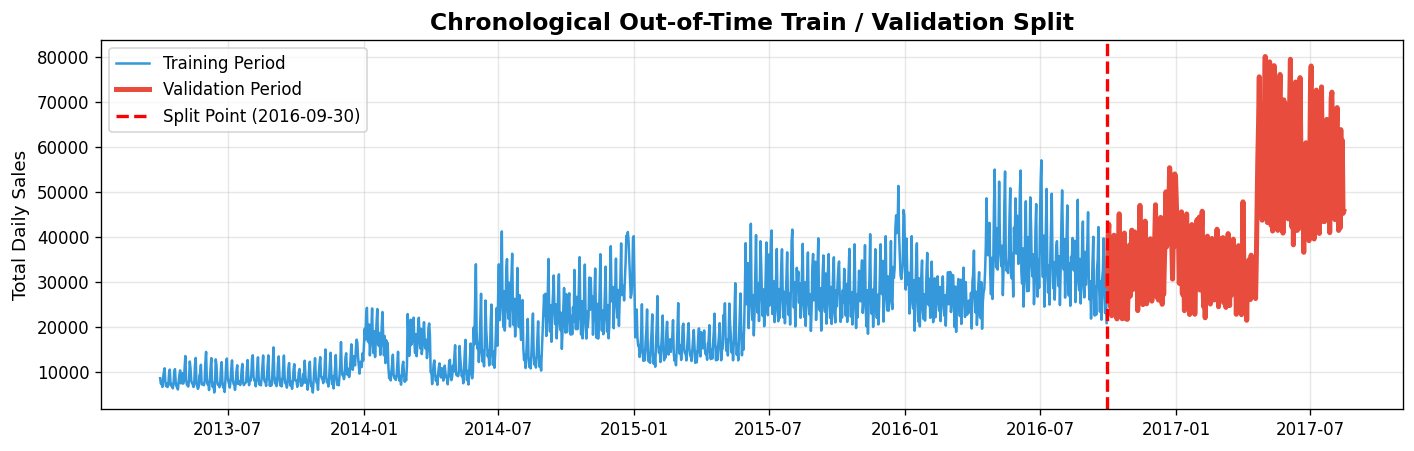

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\00_chronological_train_val_split.png


3134

In [8]:
# ── 6.1 Temporal Split Visualization ──
daily_agg = df.groupby('date')[TARGET_COL].sum().reset_index()
fig, ax = plt.subplots(figsize=(14, 4))
t_mask = daily_agg['date'] < VAL_START
ax.plot(daily_agg.loc[t_mask, 'date'], daily_agg.loc[t_mask, TARGET_COL],
        label='Training Period', color='#3498db', linewidth=1.5)
ax.plot(daily_agg.loc[~t_mask, 'date'], daily_agg.loc[~t_mask, TARGET_COL],
        label='Validation Period', color='#e74c3c', linewidth=3)
ax.axvline(pd.Timestamp(VAL_START), color='red', linestyle='--', linewidth=2,
           label=f"Split Point ({pd.Timestamp(VAL_START).date()})")
ax.set_title('Chronological Out-of-Time Train / Validation Split', fontweight='bold')
ax.set_ylabel('Total Daily Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
save_fig(fig, '00_chronological_train_val_split.png')
del daily_agg; gc.collect()


In [9]:
print(X_train.shape)
print(X_val.shape)

print(y_train.shape)
print(y_val.shape)

(3352224, 65)
(1647776, 65)
(3352224,)
(1647776,)


---
## 7️⃣ Feature Scaling

> Apply `StandardScaler` fitted **strictly on train set** to prevent data leakage.


In [10]:
# ============================================================
# 7. Feature Scaling (StandardScaler)
# ============================================================
from sklearn.preprocessing import StandardScaler


print('⏳ Fitting StandardScaler on training data...')
t0 = time.time()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)

scale_time = time.time() - t0

# Validate scaling
train_means = np.abs(X_train_scaled.mean(axis=0))
train_stds  = X_train_scaled.std(axis=0)

print(f'✅ Scaling complete in {scale_time:.2f}s')
print(f'   X_train_scaled mean range: [{train_means.min():.6f}, {train_means.max():.6f}] (should be ~0)')
print(f'   X_train_scaled std  range: [{train_stds.min():.4f}, {train_stds.max():.4f}] (should be ~1)')
print(f'   Scaled train RAM: {X_train_scaled.nbytes / 1e9:.2f} GB')
print(f'   Scaled val   RAM: {X_val_scaled.nbytes / 1e9:.2f} GB')

del train_means, train_stds
utils.memory_checkpoint('After Scaling')


⏳ Fitting StandardScaler on training data...
✅ Scaling complete in 2.46s
   X_train_scaled mean range: [0.000000, 0.000051] (should be ~0)
   X_train_scaled std  range: [1.0000, 1.0000] (should be ~1)
   Scaled train RAM: 0.87 GB
   Scaled val   RAM: 0.43 GB
[2026-07-29 22:40:50] [INFO] 🧠 RAM Checkpoint [After Scaling]: 7.14 GB


7.140277862548828

---
## 8️⃣ Evaluation Framework & Metric Engine

> Standardized metric suite: RMSLE, RMSE, MAE, MAPE, $R^2$, and runtime tracking.


In [11]:
# ============================================================
# 8. Evaluation Framework & Visualization Engine
# ============================================================
baseline_results = []

def safe_mape(y_true, y_pred, eps=1.0):
    """MAPE excluding near-zero actuals to avoid division by zero."""
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return 0.0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def validate_predictions(y_pred, model_name):
    """Check predictions for numerical instability."""
    issues = []
    n_nan = np.isnan(y_pred).sum()
    n_inf = np.isinf(y_pred).sum()
    n_neg = (y_pred < 0).sum()
    if n_nan > 0: issues.append(f'⚠️ {n_nan:,} NaN predictions')
    if n_inf > 0: issues.append(f'⚠️ {n_inf:,} Inf predictions')
    if n_neg > 0: issues.append(f'⚠️ {n_neg:,} negative predictions (will be clipped to 0)')
    if issues:
        print(f'\n   ┌── NUMERICAL STABILITY WARNING: {model_name} ──')
        for iss in issues:
            print(f'   │ {iss}')
        print(f'   └{"─" * 50}')
    return len(issues) == 0

def plot_model_diagnostics(model_name, y_true, y_pred, plot_prefix):
    """Generate per-model diagnostic visualizations."""
    n_sample = min(5000, len(y_true))
    rng = np.random.RandomState(42)
    idx = rng.choice(len(y_true), size=n_sample, replace=False)
    yt, yp = y_true[idx], y_pred[idx]
    residuals = yt - yp
    abs_errors = np.abs(residuals)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Actual vs Predicted Scatter
    axes[0,0].scatter(yt, yp, alpha=0.15, s=8, color='#2ecc71')
    lim = max(np.percentile(yt, 99), np.percentile(yp, 99))
    axes[0,0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect (y=x)')
    axes[0,0].set_xlim(0, lim); axes[0,0].set_ylim(0, lim)
    axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')
    axes[0,0].set_title('Actual vs Predicted', fontweight='bold')
    axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

    # 2. Residual Histogram
    axes[0,1].hist(residuals, bins=60, color='#9b59b6', edgecolor='black', alpha=0.75)
    axes[0,1].axvline(0, color='red', linestyle='--', lw=2)
    axes[0,1].set_title('Residual Distribution', fontweight='bold')
    axes[0,1].set_xlabel('Residual (Actual − Predicted)')
    axes[0,1].grid(True, alpha=0.3)

    # 3. Residual Scatter
    axes[0,2].scatter(yp, residuals, alpha=0.15, s=8, color='#e67e22')
    axes[0,2].axhline(0, color='red', linestyle='--', lw=2)
    axes[0,2].set_xlabel('Predicted'); axes[0,2].set_ylabel('Residual')
    axes[0,2].set_title('Residual vs Predicted', fontweight='bold')
    axes[0,2].grid(True, alpha=0.3)

    # 4. Prediction Distribution
    axes[1,0].hist(yp, bins=60, alpha=0.6, color='#3498db', edgecolor='black', label='Predicted')
    axes[1,0].hist(yt, bins=60, alpha=0.4, color='#e74c3c', edgecolor='black', label='Actual')
    axes[1,0].set_title('Prediction vs Target Distribution', fontweight='bold')
    axes[1,0].legend(fontsize=9); axes[1,0].grid(True, alpha=0.3)

    # 5. Absolute Error Distribution
    axes[1,1].hist(abs_errors, bins=60, color='#1abc9c', edgecolor='black', alpha=0.75)
    axes[1,1].set_title('Absolute Error Distribution', fontweight='bold')
    axes[1,1].set_xlabel('|Actual − Predicted|')
    axes[1,1].grid(True, alpha=0.3)

    # 6. Sampled Actual vs Predicted Line
    line_n = min(200, n_sample)
    axes[1,2].plot(range(line_n), yt[:line_n], label='Actual', color='#e74c3c', lw=1.2)
    axes[1,2].plot(range(line_n), yp[:line_n], label='Predicted', color='#3498db', lw=1.2, alpha=0.8)
    axes[1,2].set_title('Actual vs Predicted (Sampled)', fontweight='bold')
    axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)

    plt.suptitle(f'Diagnostic Suite — {model_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_fig(fig, f'{plot_prefix}_diagnostics.png')
    del yt, yp, residuals, abs_errors, idx

def evaluate_model(model_name, y_true, y_pred, train_time=0.0, pred_time=0.0,
                   model_obj=None, filename=None, plot_prefix=None):
    """Full evaluation pipeline: validate → metrics → save → visualize → log."""
    print(f'\n{"─" * 60}')
    print(f'📊 Evaluating: {model_name}')
    print(f'{"─" * 60}')

    # Numerical stability check
    validate_predictions(y_pred, model_name)
    y_t = np.clip(y_true, 0, None)
    y_p = np.clip(y_pred, 0, None)
    y_p = np.nan_to_num(y_p, nan=0.0, posinf=0.0, neginf=0.0)

    # Compute metrics
    rmse  = float(np.sqrt(mean_squared_error(y_t, y_p)))
    mae   = float(mean_absolute_error(y_t, y_p))
    rmsle = float(np.sqrt(mean_squared_error(np.log1p(y_t), np.log1p(y_p))))
    r2    = float(r2_score(y_t, y_p))
    mape  = safe_mape(y_t, y_p)

    # Save model
    model_size_mb = 0.0
    if model_obj is not None and filename is not None:
        save_path = MODELS_DIR / filename
        joblib.dump(model_obj, save_path, compress=3)
        model_size_mb = float(save_path.stat().st_size / (1024 * 1024))
        print(f'   💾 Model saved → {save_path.name} ({model_size_mb:.2f} MB)')

    res = {
        'Model': model_name,
        'RMSLE': round(rmsle, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'MAPE': round(mape, 2),
        'R2_Score': round(r2, 4),
        'Train_Time_s': round(train_time, 3),
        'Pred_Time_s': round(pred_time, 4),
        'Model_Size_MB': round(model_size_mb, 3)
    }
    baseline_results.append(res)

    # Print metrics table
    print(f'\n   ┌─── Performance Metrics ───────────────────────────┐')
    print(f'   │ RMSLE  : {rmsle:>10.4f}  (Primary metric)           │')
    print(f'   │ RMSE   : {rmse:>10.2f}                              │')
    print(f'   │ MAE    : {mae:>10.2f}                              │')
    print(f'   │ MAPE   : {mape:>9.2f}%                             │')
    print(f'   │ R²     : {r2:>10.4f}                              │')
    print(f'   ├─── Execution Metrics ───────────────────────────┤')
    print(f'   │ Train  : {train_time:>8.3f}s                            │')
    print(f'   │ Predict: {pred_time:>8.4f}s                            │')
    print(f'   │ Size   : {model_size_mb:>8.3f} MB                          │')
    print(f'   └────────────────────────────────────────────────┘')

    # Prediction statistics
    print(f'\n   Prediction Stats: mean={y_p.mean():.2f}, std={y_p.std():.2f}, '
          f'min={y_p.min():.2f}, max={y_p.max():.2f}')

    # Generate diagnostic plots
    if plot_prefix:
        try:
            plot_model_diagnostics(model_name, y_t, y_p, plot_prefix)
        except Exception as e:
            print(f'   ⚠️ Diagnostic plot failed: {e}')

    utils.memory_checkpoint(f'After {model_name}')
    return res

print('✅ Evaluation framework loaded.')


✅ Evaluation framework loaded.


---
## 9️⃣ Baseline Model Training & Evaluation

> Sequential training and evaluation of 8 baseline models.


### 9️⃣.1 Baseline 1 — Global Mean Predictor

#### 📖 Model Overview

| Property | Detail |
|----------|--------|
| **Purpose** | Establish the absolute simplest lower bound |
| **Mathematical Formulation** | $\hat{y} = \bar{y}_{train} = \frac{1}{n}\sum_{i=1}^{n} y_i$ |
| **How It Works** | Predicts the global average of training sales for every observation |
| **Advantages** | Zero computation, zero parameters, perfect reproducibility |
| **Disadvantages** | Ignores all features, all temporal patterns, all store/item differences |
| **Business Use Case** | Budget planning when no historical data is available |
| **Computational Complexity** | $O(n)$ for mean, $O(1)$ for prediction |
| **Interpretability** | Maximum — single number |
| **Scaling Required** | ❌ No — no feature input |
| **Feature Selection** | None — ignores all features |
| **Suitable Dataset Size** | Any |
| **When NOT to Use** | When any feature signal exists (always — this is a baseline only) |



────────────────────────────────────────────────────────────
📊 Evaluating: Global Mean
────────────────────────────────────────────────────────────

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     1.0071  (Primary metric)           │
   │ RMSE   :      15.50                              │
   │ MAE    :       7.38                              │
   │ MAPE   :    118.68%                             │
   │ R²     :    -0.0000                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :    0.000s                            │
   │ Predict:   0.0047s                            │
   │ Size   :    0.000 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=7.97, std=0.00, min=7.97, max=7.97


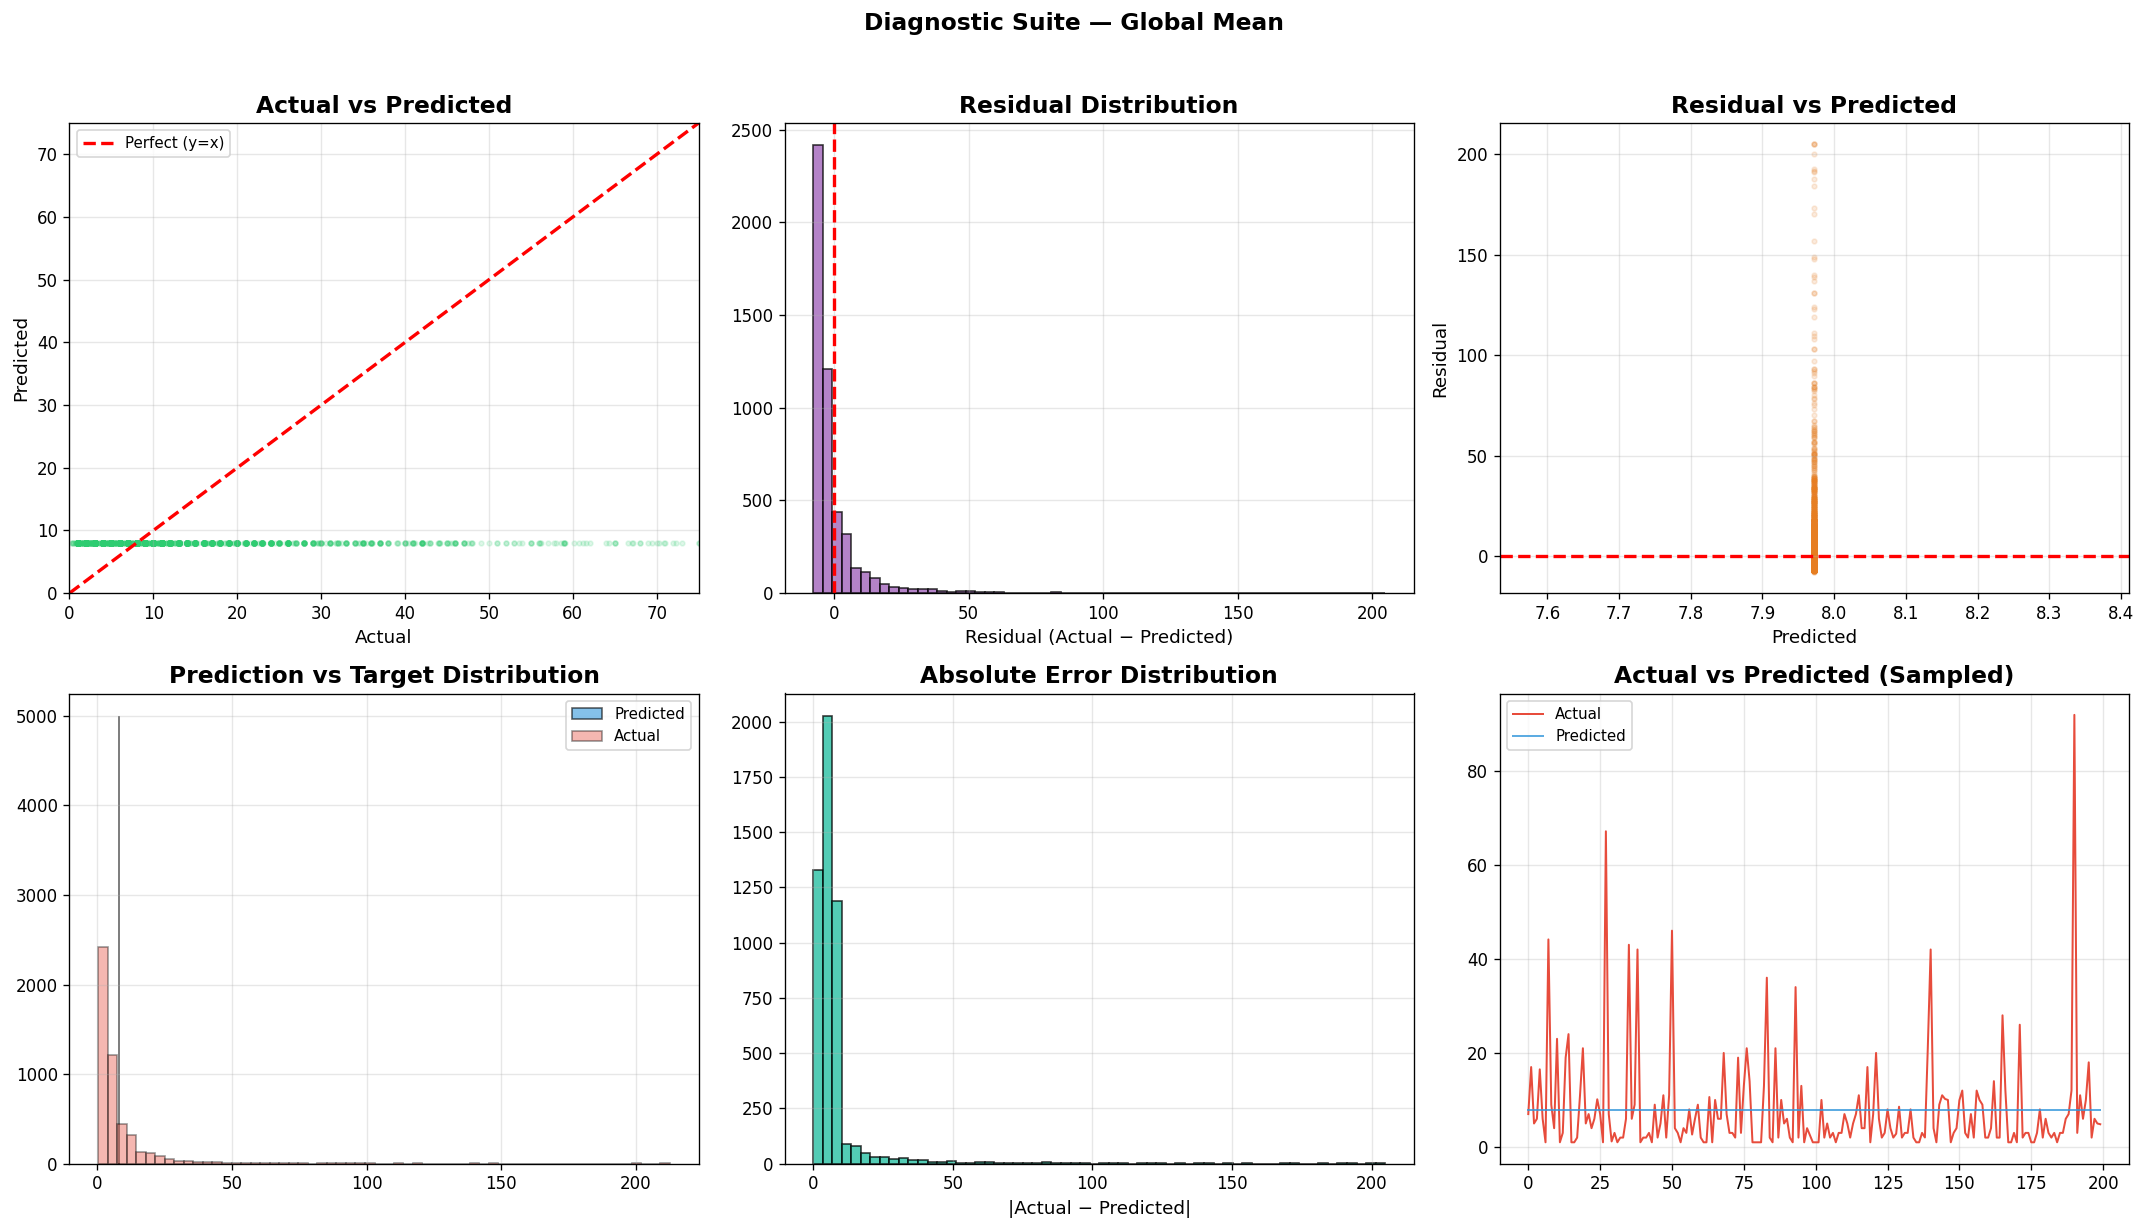

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m01_mean_diagnostics.png
[2026-07-29 22:40:51] [INFO] 🧠 RAM Checkpoint [After Global Mean]: 7.17 GB


In [12]:
# ── Baseline 1: Global Mean ──
import traceback

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)


try:
    t0 = time.time()
    mean_val = float(np.mean(y_train))
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.full(len(y_val), mean_val, dtype=np.float32)
    pred_time = time.time() - t0

    evaluate_model('Global Mean', y_val, y_pred, train_time, pred_time,
                   plot_prefix='m01_mean')
    del y_pred; gc.collect()
except Exception as e:
    print(f'❌ Global Mean failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Global Mean

- **What happened:** The model computed a single average value from training sales and used it for all predictions.
- **Convergence:** Not applicable — no iterative optimization.
- **Underfitting:** Extreme — this model underfits by design.
- **Overfitting:** Impossible — zero parameters.
- **Prediction Distribution:** Completely flat — zero variance.
- **Production Recommendation:** ❌ Never use alone. Serves only as a reference floor.
- **Key Takeaway:** Any model scoring worse than this has negative value.


### 9️⃣.2 Baseline 2 — Global Median Predictor

| Property | Detail |
|----------|--------|
| **Purpose** | Robust central tendency baseline |
| **Mathematical Formulation** | $\hat{y} = \text{Median}(y_{train})$ |
| **How It Works** | Predicts the 50th percentile of training sales |
| **Advantages** | Insensitive to extreme outliers and promotional spikes |
| **Disadvantages** | Still ignores all features and patterns |
| **Business Use Case** | Conservative baseline for inventory — avoids overstock from outliers |
| **Computational Complexity** | $O(n \log n)$ for sorting, $O(1)$ for prediction |
| **Interpretability** | Maximum |
| **Scaling Required** | ❌ No |
| **When NOT to Use** | When data is symmetric (mean ≈ median) |



────────────────────────────────────────────────────────────
📊 Evaluating: Global Median
────────────────────────────────────────────────────────────

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.8756  (Primary metric)           │
   │ RMSE   :      16.00                              │
   │ MAE    :       6.12                              │
   │ MAPE   :     55.70%                             │
   │ R²     :    -0.0658                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :    0.030s                            │
   │ Predict:   0.0033s                            │
   │ Size   :    0.000 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=4.00, std=0.00, min=4.00, max=4.00


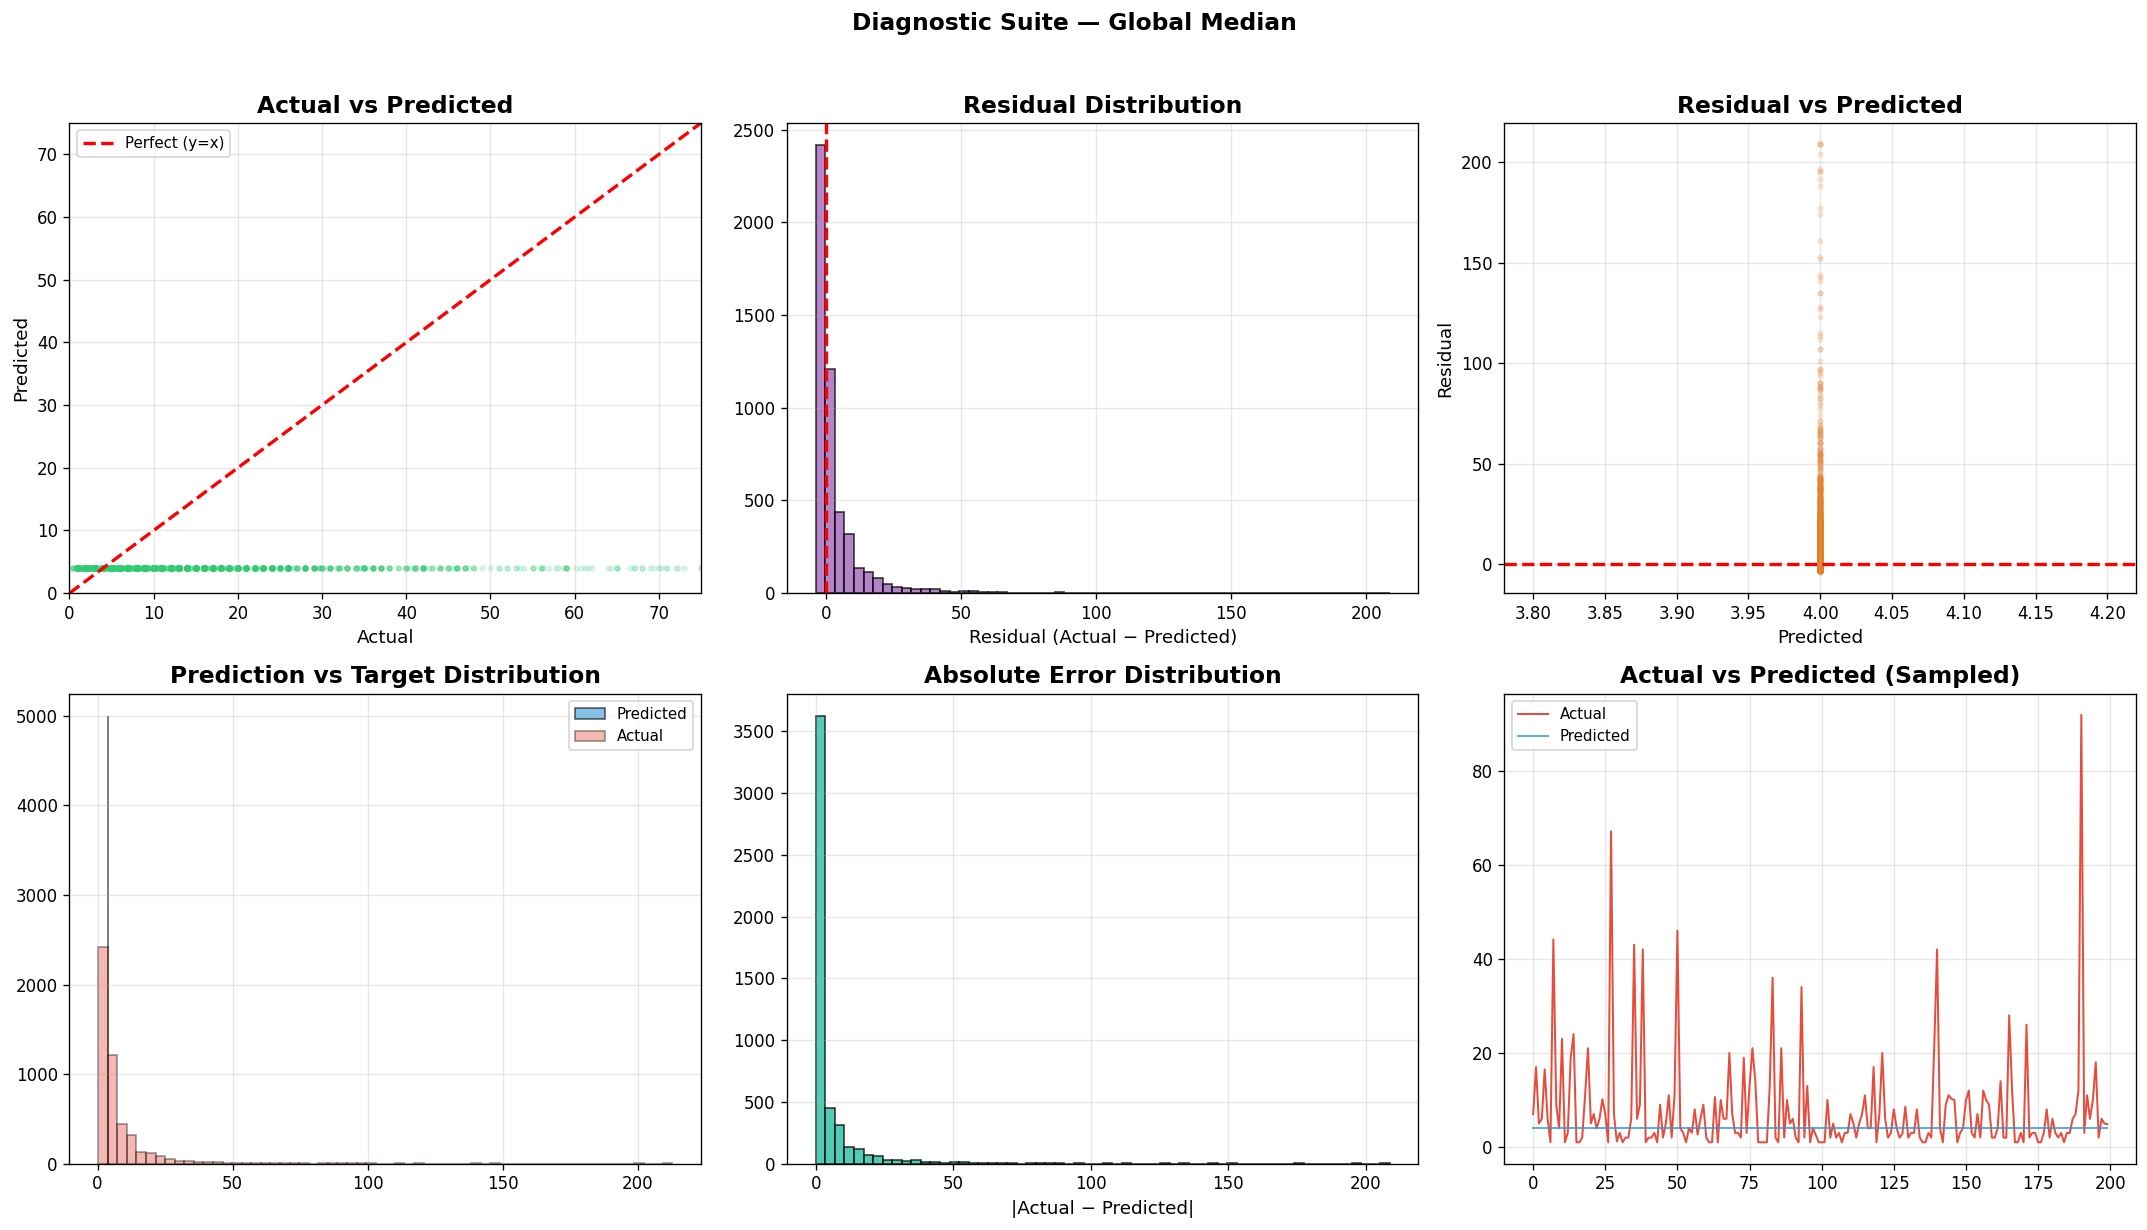

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m02_median_diagnostics.png
[2026-07-29 22:40:53] [INFO] 🧠 RAM Checkpoint [After Global Median]: 7.17 GB


In [13]:
# ── Baseline 2: Global Median ──
try:
    t0 = time.time()
    median_val = float(np.median(y_train))
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.full(len(y_val), median_val, dtype=np.float32)
    pred_time = time.time() - t0

    evaluate_model('Global Median', y_val, y_pred, train_time, pred_time,
                   plot_prefix='m02_median')
    del y_pred; gc.collect()
except Exception as e:
    print(f'❌ Global Median failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Global Median

- **What happened:** Used the 50th percentile as a constant prediction.
- **vs Mean:** If RMSLE is better, the target distribution is right-skewed (common in retail sales).
- **Underfitting:** Extreme — same as mean baseline.
- **Production Recommendation:** ❌ Never use alone. But useful as a robust fallback.


### 9️⃣.3 Baseline 3 — Seasonal Naive ($t-7$)

| Property | Detail |
|----------|--------|
| **Purpose** | Capture weekly seasonality |
| **Mathematical Formulation** | $\hat{y}_t = y_{t-7}$ |
| **How It Works** | Predicts sales equal to the same day of the previous week |
| **Advantages** | Captures strong weekly demand cycles (weekday vs weekend) |
| **Disadvantages** | Fails for trend, holidays, promotions, and non-weekly patterns |
| **Business Use Case** | Short-term weekly replenishment planning |
| **Computational Complexity** | $O(1)$ — simple lookback |
| **Interpretability** | High — "last week same day" |
| **Scaling Required** | ❌ No |
| **When NOT to Use** | When trend dominates seasonality |



────────────────────────────────────────────────────────────
📊 Evaluating: Seasonal Naive (t-7)
────────────────────────────────────────────────────────────

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.7316  (Primary metric)           │
   │ RMSE   :      10.22                              │
   │ MAE    :       4.51                              │
   │ MAPE   :     71.26%                             │
   │ R²     :     0.5656                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :    0.000s                            │
   │ Predict:   0.0022s                            │
   │ Size   :    0.000 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=7.85, std=15.41, min=0.00, max=212.76


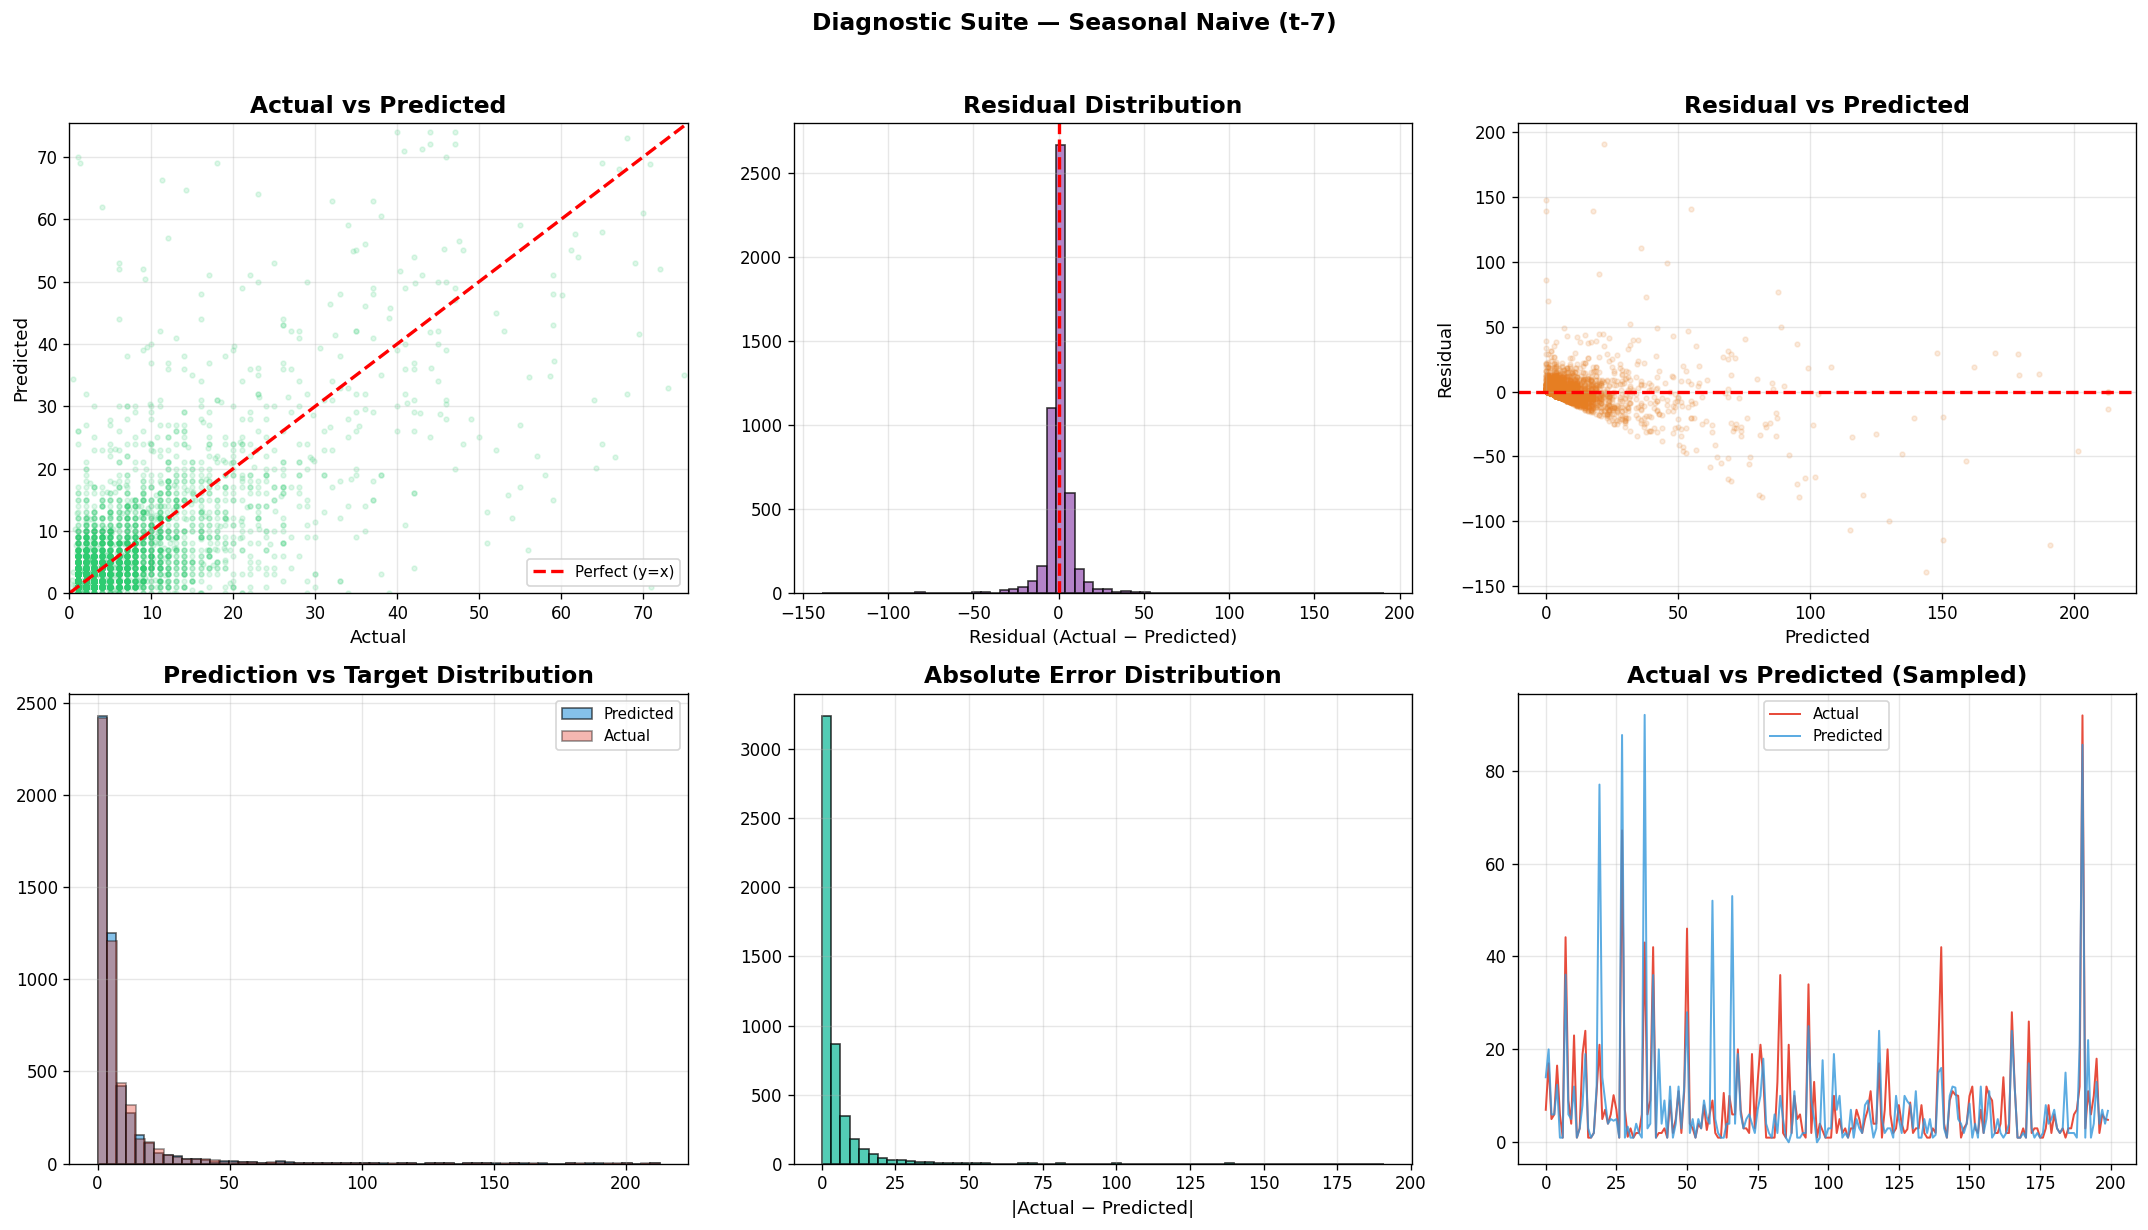

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m03_snaive_diagnostics.png
[2026-07-29 22:40:54] [INFO] 🧠 RAM Checkpoint [After Seasonal Naive (t-7)]: 7.17 GB


In [14]:
# ── Baseline 3: Seasonal Naive (t-7) ──
try:
    train_time = 0.0
    t0 = time.time()
    if snaive_vals is not None:
        y_pred = snaive_vals.copy()
    else:
        y_pred = np.full(len(y_val), float(np.mean(y_train)), dtype=np.float32)
        print('   ⚠️ sales_lag_7 not found, falling back to mean.')
    pred_time = time.time() - t0

    evaluate_model('Seasonal Naive (t-7)', y_val, y_pred, train_time, pred_time,
                   plot_prefix='m03_snaive')
    del y_pred; gc.collect()
except Exception as e:
    print(f'❌ Seasonal Naive failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Seasonal Naive

- **What happened:** Predicted each day's sales using the same day from the previous week.
- **Expected:** Should significantly beat mean/median if weekly seasonality is strong.
- **Limitation:** Cannot adapt to trend changes, promotions, or holidays.
- **Production Recommendation:** ❌ Too simplistic, but reveals the strength of weekly patterns.


### 📊 Linear Model Analysis Helper

Before training linear models, we define a reusable function for coefficient analysis.


In [15]:
# ── Linear Model Coefficient Analysis Helper ──
def analyze_linear_coefficients(model, feature_names, model_name, plot_prefix, is_lasso=False):
    """Analyze and visualize coefficients for linear models."""
    coefs = model.coef_.flatten()
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs,
        'Abs_Coefficient': np.abs(coefs)
    }).sort_values('Abs_Coefficient', ascending=False)

    # Print coefficient statistics
    print(f'\n   ┌─── Coefficient Statistics ─────────────────────┐')
    print(f'   │ Total Features  : {len(coefs):>6}                       │')
    print(f'   │ Non-zero        : {(coefs != 0).sum():>6}                       │')
    print(f'   │ Zero            : {(coefs == 0).sum():>6}                       │')
    print(f'   │ Mean |coef|     : {np.abs(coefs).mean():>10.6f}                 │')
    print(f'   │ Max |coef|      : {np.abs(coefs).max():>10.6f}                 │')
    print(f'   │ Intercept       : {float(model.intercept_):>10.6f}                 │')
    print(f'   └────────────────────────────────────────────────┘')

    # Top positive & negative
    top_n = min(10, len(coef_df))
    print(f'\n   Top {top_n} Positive Coefficients:')
    pos = coef_df[coef_df['Coefficient'] > 0].head(top_n)
    if len(pos) > 0:
        for _, row in pos.iterrows():
            print(f'      {row["Feature"]:35s} : {row["Coefficient"]:+.6f}')

    print(f'\n   Top {top_n} Negative Coefficients:')
    neg = coef_df[coef_df['Coefficient'] < 0].sort_values('Coefficient').head(top_n)
    if len(neg) > 0:
        for _, row in neg.iterrows():
            print(f'      {row["Feature"]:35s} : {row["Coefficient"]:+.6f}')

    # Lasso sparsity
    if is_lasso:
        n_zero = (coefs == 0).sum()
        sparsity = n_zero / len(coefs) * 100
        print(f'\n   ┌─── Lasso Feature Sparsity ─────────────────────┐')
        print(f'   │ Zero Coefficients    : {n_zero:>6} / {len(coefs)}              │')
        print(f'   │ Remaining Features   : {len(coefs) - n_zero:>6}                       │')
        print(f'   │ Sparsity Percentage  : {sparsity:>6.1f}%                      │')
        print(f'   └────────────────────────────────────────────────┘')

    # Coefficient magnitude plot (top 20)
    top20 = coef_df.head(20)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top20['Coefficient']]
    axes[0].barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='black')
    axes[0].set_title(f'Top 20 Coefficients — {model_name}', fontweight='bold')
    axes[0].set_xlabel('Coefficient Value')
    axes[0].axvline(0, color='black', lw=1)
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)

    # Coefficient distribution
    axes[1].hist(coefs, bins=50, color='#3498db', edgecolor='black', alpha=0.75)
    axes[1].axvline(0, color='red', linestyle='--', lw=2)
    axes[1].set_title(f'Coefficient Distribution — {model_name}', fontweight='bold')
    axes[1].set_xlabel('Coefficient Value')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_fig(fig, f'{plot_prefix}_coefficients.png')
    del coef_df, top20, pos, neg

print('✅ Linear analysis helper loaded.')


✅ Linear analysis helper loaded.


### 9️⃣.4 Baseline 4 — Linear Regression (OLS)

| Property | Detail |
|----------|--------|
| **Purpose** | Unregularized parametric linear baseline |
| **Mathematical Formulation** | $\hat{y} = X\beta + \epsilon$, minimize $\|y - X\beta\|^2$ |
| **How It Works** | Finds the hyperplane that minimizes the sum of squared residuals |
| **Advantages** | Fast, interpretable, closed-form solution |
| **Disadvantages** | Sensitive to multicollinearity, no regularization, can overfit |
| **Business Use Case** | Quick feature importance assessment via coefficients |
| **Computational Complexity** | $O(n \cdot p^2)$ for training |
| **Interpretability** | High — direct coefficient interpretation |
| **Scaling Required** | ✅ Yes — coefficient magnitudes reflect feature scale |
| **Feature Selection** | None — uses all features |
| **When NOT to Use** | High multicollinearity, many irrelevant features |

> **Note:** We train on $\log(1+y)$ to stabilize variance and use StandardScaler for features.



────────────────────────────────────────────────────────────
📊 Evaluating: Linear Regression
────────────────────────────────────────────────────────────

   ┌── NUMERICAL STABILITY WARNING: Linear Regression ──
   │ ⚠️ 290,638 negative predictions (will be clipped to 0)
   └──────────────────────────────────────────────────
   💾 Model saved → baseline_linear_regression.joblib (0.00 MB)

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     1.0162  (Primary metric)           │
   │ RMSE   :     488.31                              │
   │ MAE    :      12.34                              │
   │ MAPE   :     68.33%                             │
   │ R²     :  -991.5613                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :    5.368s                            │
   │ Predict:   0.1015s                            │
   │ Size   :    0.001 MB                          │
   └────────────────────────────────────────────────┘

   P

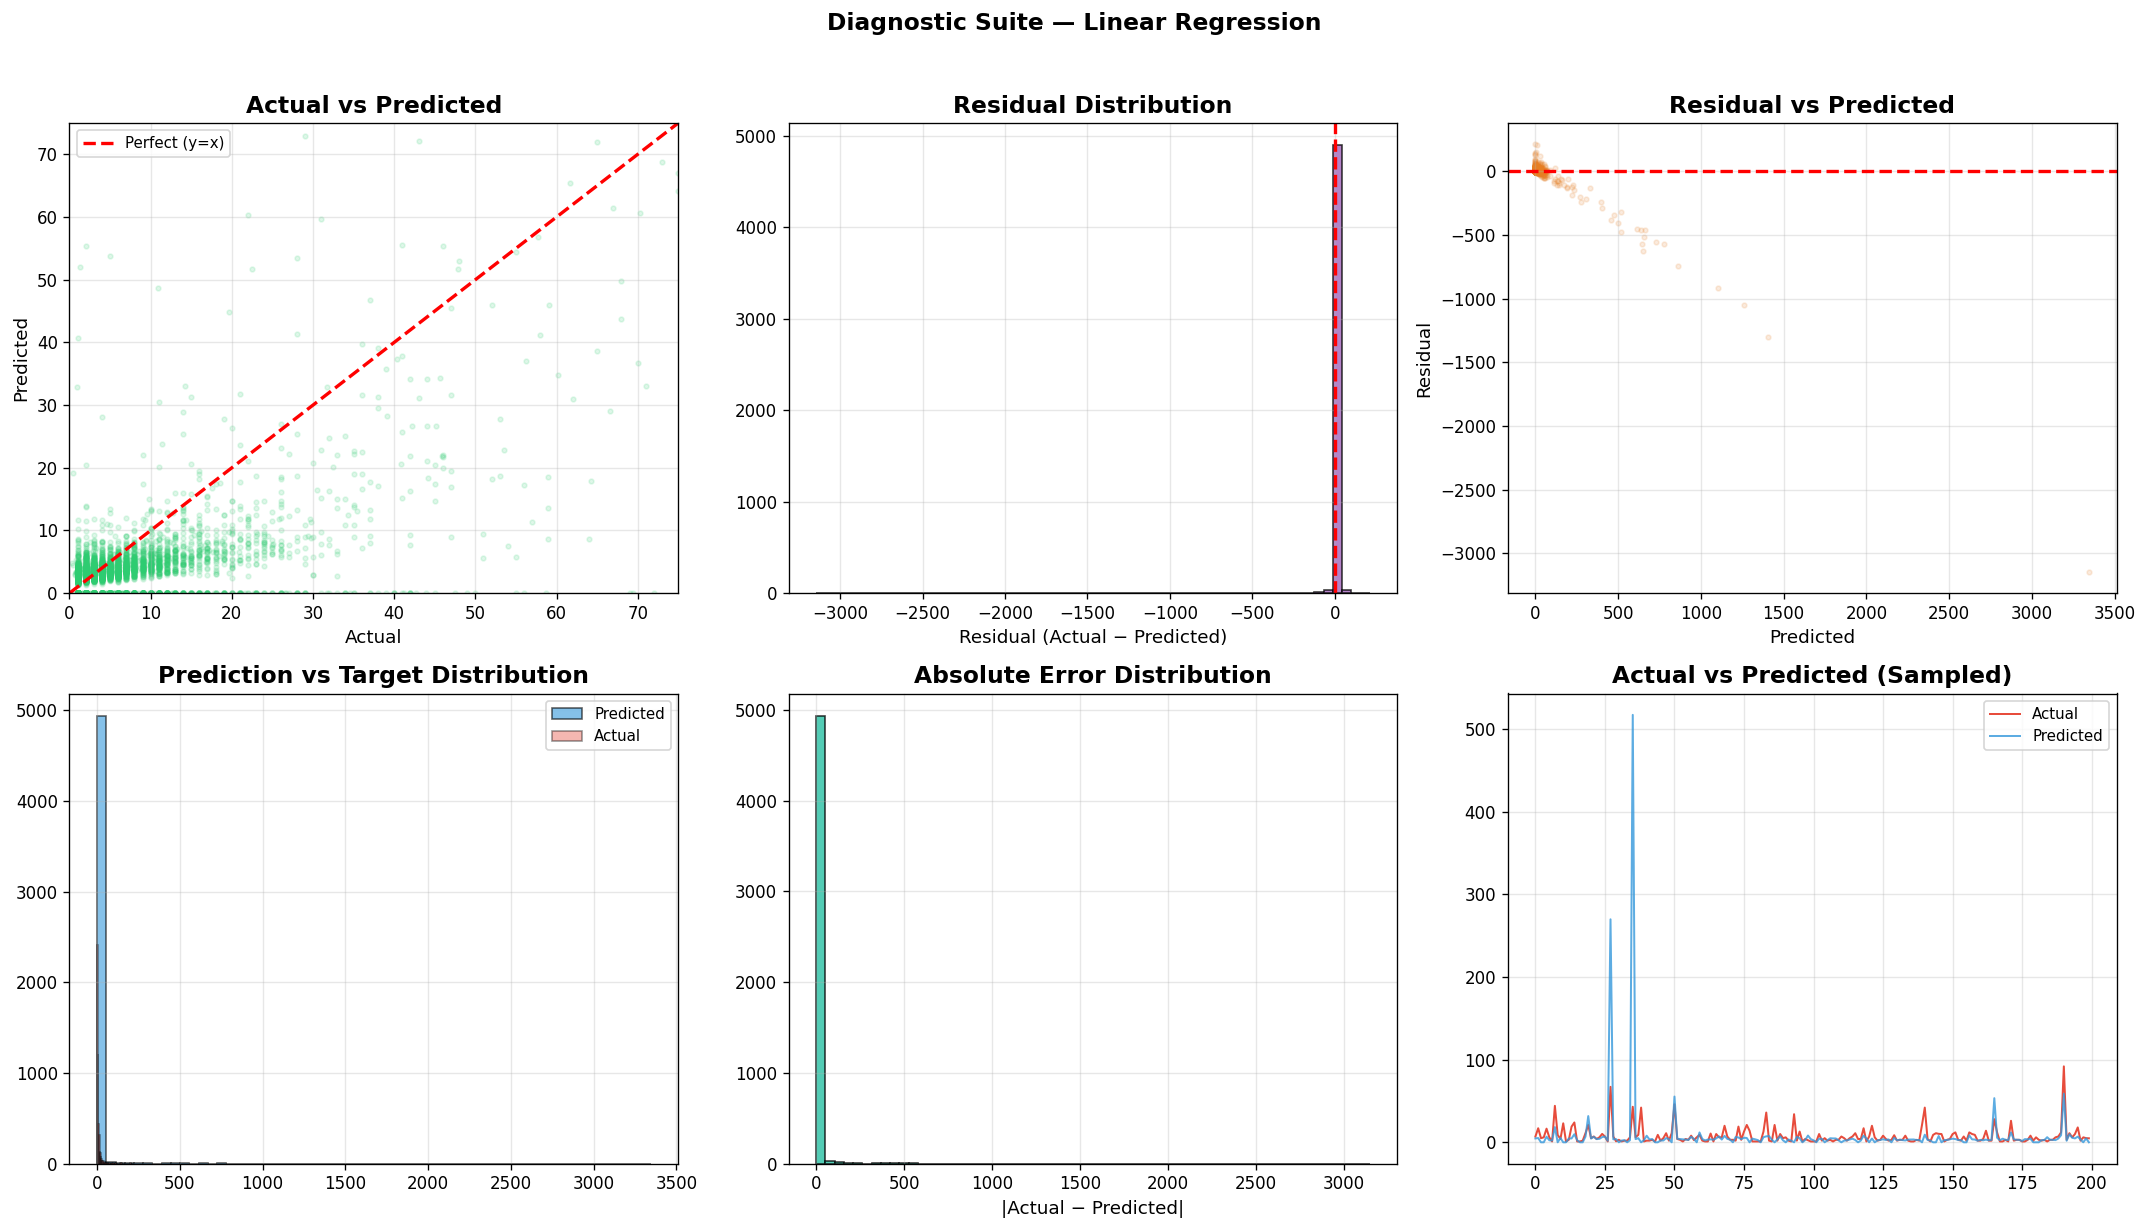

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m04_ols_diagnostics.png
[2026-07-29 22:41:01] [INFO] 🧠 RAM Checkpoint [After Linear Regression]: 6.14 GB

   ┌─── Coefficient Statistics ─────────────────────┐
   │ Total Features  :     65                       │
   │ Non-zero        :     65                       │
   │ Zero            :      0                       │
   │ Mean |coef|     :   1.182305                 │
   │ Max |coef|      :  24.087000                 │
   │ Intercept       :   1.686594                 │
   └────────────────────────────────────────────────┘

   Top 10 Positive Coefficients:
      state_freq                          : +24.087000
      type_freq                           : +13.990542
      cluster_freq                        : +10.959127
      city_freq                           : +2.287645
      sales_roll_mean_7                   : +0.448471
      sales_roll_max_7                    : +0.408282
      sales_ewma_28 

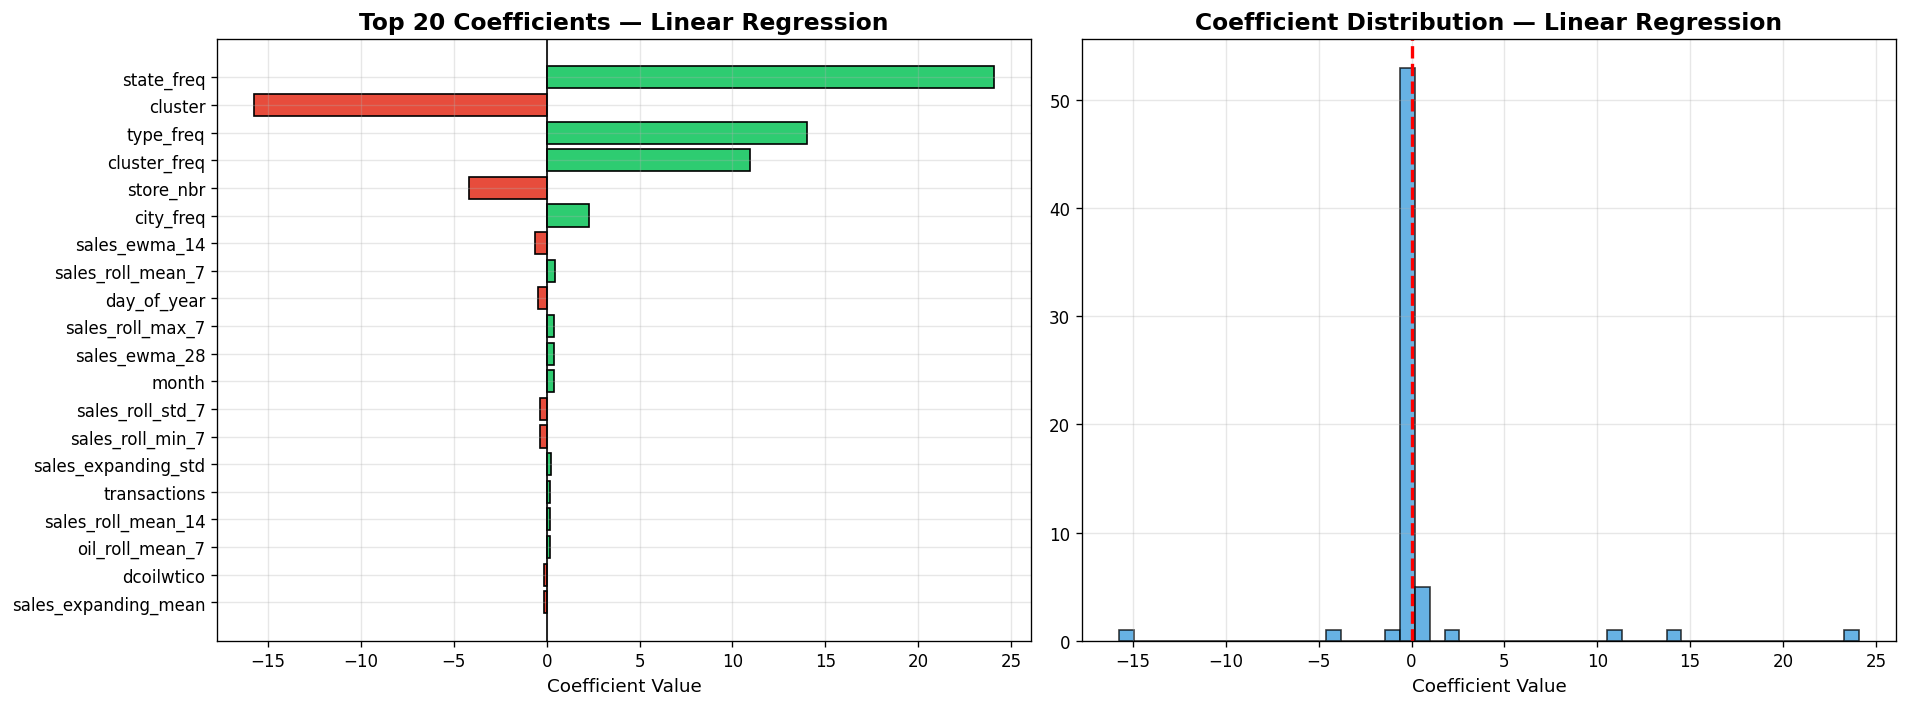

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m04_ols_coefficients.png


In [16]:
# ── Baseline 4: Linear Regression ──
try:
    y_train_log = np.log1p(np.clip(y_train, 0, None))

    t0 = time.time()
    model = LinearRegression()
    model.fit(X_train_scaled, y_train_log)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.expm1(model.predict(X_val_scaled)).astype(np.float32)
    pred_time = time.time() - t0

    evaluate_model('Linear Regression', y_val, y_pred, train_time, pred_time,
                   model, 'baseline_linear_regression.joblib', plot_prefix='m04_ols')
    analyze_linear_coefficients(model, feature_cols, 'Linear Regression', 'm04_ols')
    del model, y_pred; gc.collect()
except Exception as e:
    print(f'❌ Linear Regression failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Linear Regression

- **Convergence:** OLS has a closed-form solution — always converges.
- **Scaling Impact:** StandardScaler ensures all coefficients are on the same scale, making direct comparison valid.
- **Underfitting Risk:** If R² is low, the relationship between features and target is non-linear.
- **Overfitting Risk:** Without regularization, can overfit if features >> samples or multicollinearity exists.
- **Production Recommendation:** ⚠️ Use as interpretability reference, not for production deployment.


### 9️⃣.5 Baseline 5 — Ridge Regression ($L_2$)

| Property | Detail |
|----------|--------|
| **Purpose** | Stabilize linear regression against multicollinearity |
| **Mathematical Formulation** | Minimize $\|y - X\beta\|^2 + \alpha\|\beta\|_2^2$ |
| **How It Works** | Adds $L_2$ penalty that shrinks coefficients toward zero without eliminating them |
| **Advantages** | Handles correlated features, always has a unique solution |
| **Disadvantages** | Does not perform feature selection (all features retained) |
| **Business Use Case** | Stable forecasting with correlated lag/rolling features |
| **Computational Complexity** | $O(n \cdot p^2)$ |
| **Scaling Required** | ✅ Yes — $L_2$ penalty is scale-dependent |
| **When NOT to Use** | When true feature sparsity is needed |



────────────────────────────────────────────────────────────
📊 Evaluating: Ridge Regression
────────────────────────────────────────────────────────────

   ┌── NUMERICAL STABILITY WARNING: Ridge Regression ──
   │ ⚠️ 60 negative predictions (will be clipped to 0)
   └──────────────────────────────────────────────────
   💾 Model saved → baseline_ridge.joblib (0.00 MB)

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.6203  (Primary metric)           │
   │ RMSE   :     496.96                              │
   │ MAE    :      12.56                              │
   │ MAPE   :     62.64%                             │
   │ R²     : -1027.0338                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :   23.707s                            │
   │ Predict:   0.2570s                            │
   │ Size   :    0.001 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: me

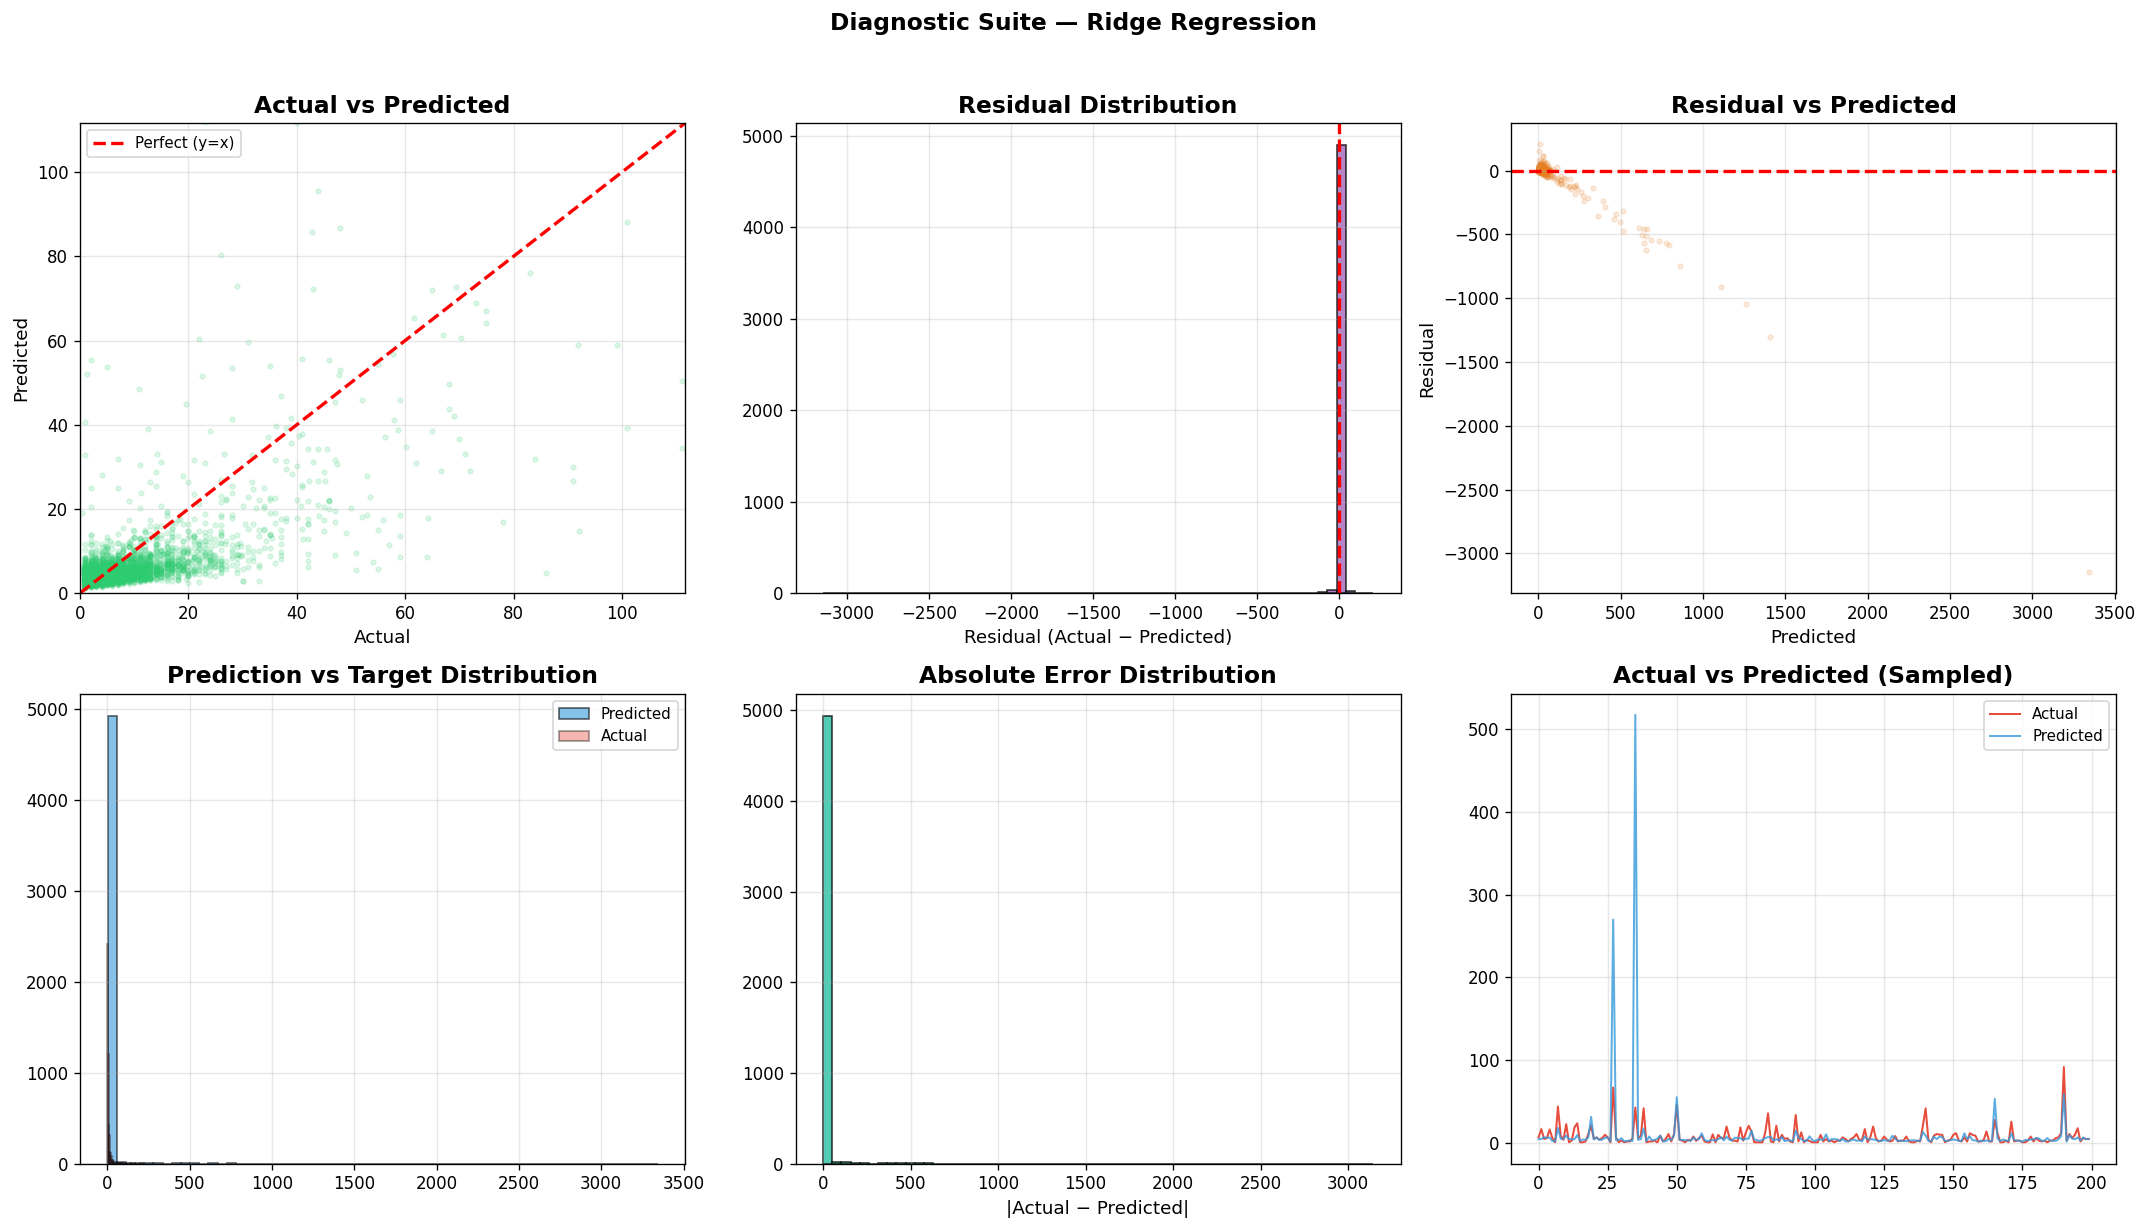

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m05_ridge_diagnostics.png
[2026-07-29 22:41:27] [INFO] 🧠 RAM Checkpoint [After Ridge Regression]: 0.48 GB

   ┌─── Coefficient Statistics ─────────────────────┐
   │ Total Features  :     65                       │
   │ Non-zero        :     65                       │
   │ Zero            :      0                       │
   │ Mean |coef|     :   0.086648                 │
   │ Max |coef|      :   0.623282                 │
   │ Intercept       :   1.686606                 │
   └────────────────────────────────────────────────┘

   Top 10 Positive Coefficients:
      sales_roll_mean_7                   : +0.448535
      sales_roll_max_7                    : +0.408278
      sales_ewma_28                       : +0.405215
      month                               : +0.372952
      sales_expanding_std                 : +0.252444
      transactions                        : +0.179576
      oil_roll_mean_7 

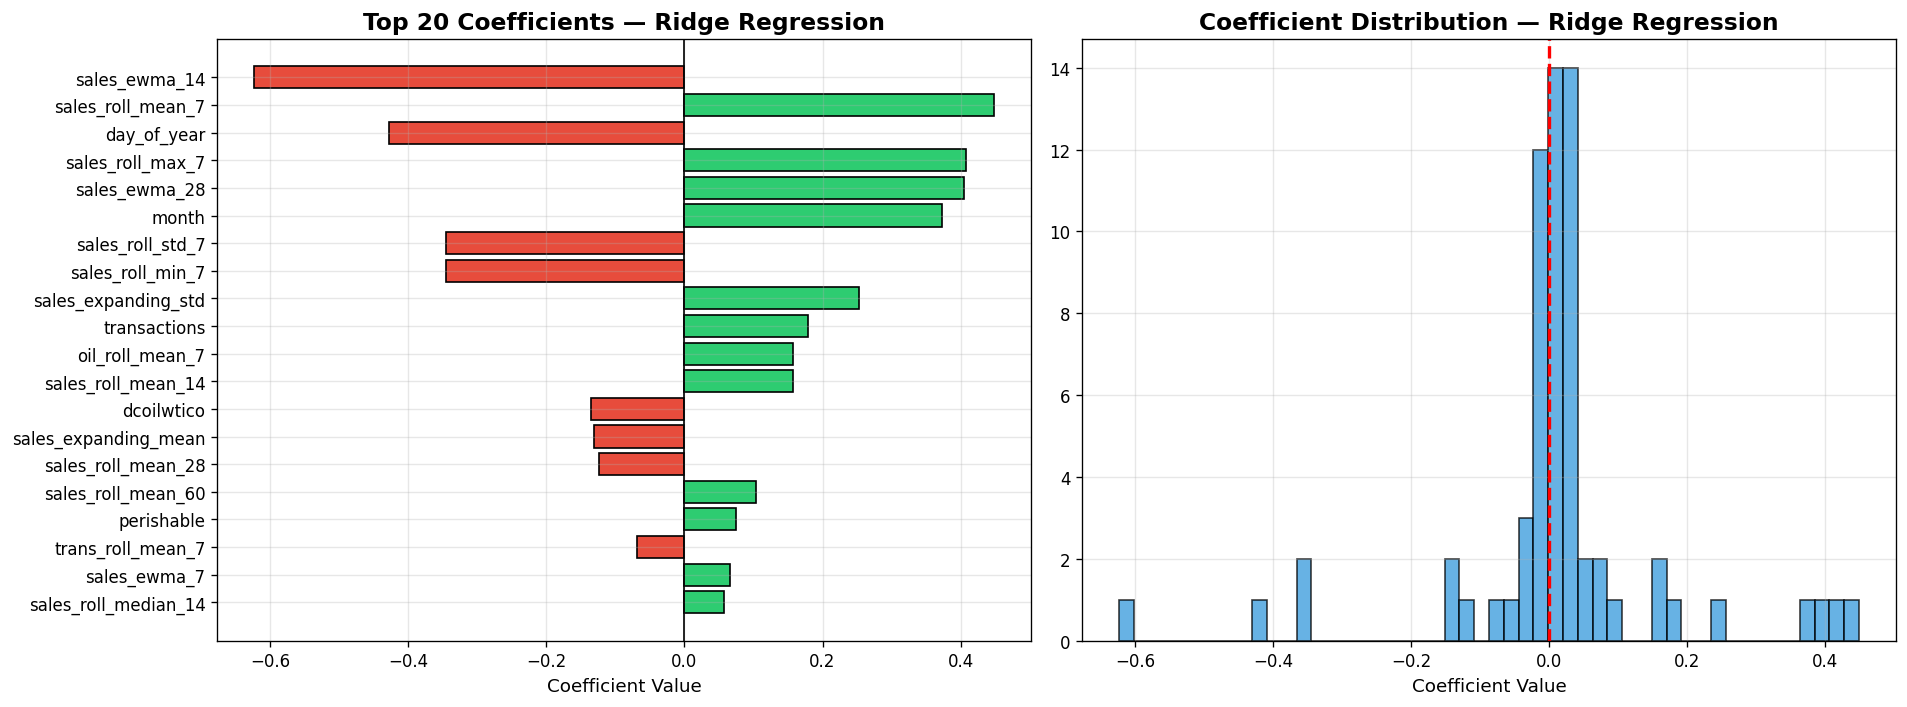

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m05_ridge_coefficients.png


In [17]:
# ── Baseline 5: Ridge Regression ──
try:
    y_train_log = np.log1p(np.clip(y_train, 0, None))

    t0 = time.time()
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_scaled, y_train_log)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.expm1(model.predict(X_val_scaled)).astype(np.float32)
    pred_time = time.time() - t0

    evaluate_model('Ridge Regression', y_val, y_pred, train_time, pred_time,
                   model, 'baseline_ridge.joblib', plot_prefix='m05_ridge')
    analyze_linear_coefficients(model, feature_cols, 'Ridge Regression', 'm05_ridge')
    del model, y_pred; gc.collect()
except Exception as e:
    print(f'❌ Ridge Regression failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Ridge Regression

- **vs OLS:** Ridge should produce similar or slightly better metrics, with smaller coefficient magnitudes.
- **Multicollinearity:** The $L_2$ penalty stabilizes coefficients when lag/rolling features are highly correlated.
- **All Features Retained:** Ridge shrinks but never zeroes coefficients — all features remain active.
- **Production Recommendation:** ⚠️ Better than OLS for this dataset, but still limited by linearity.


### 9️⃣.6 Baseline 6 — Lasso Regression ($L_1$)

| Property | Detail |
|----------|--------|
| **Purpose** | Automatic feature selection via coefficient sparsity |
| **Mathematical Formulation** | Minimize $\|y - X\beta\|^2 + \alpha\|\beta\|_1$ |
| **How It Works** | $L_1$ penalty drives weak coefficients exactly to zero |
| **Advantages** | Built-in feature selection, sparse interpretable model |
| **Disadvantages** | Can arbitrarily select one of correlated features, ignoring the rest |
| **Business Use Case** | Identifying the most important demand drivers |
| **Computational Complexity** | $O(n \cdot p)$ per iteration (coordinate descent) |
| **Scaling Required** | ✅ Yes — $L_1$ penalty is scale-dependent |
| **Feature Selection** | ✅ Yes — automatic sparsity |
| **When NOT to Use** | When all features are known to be important |



────────────────────────────────────────────────────────────
📊 Evaluating: Lasso Regression
────────────────────────────────────────────────────────────
   💾 Model saved → baseline_lasso.joblib (0.00 MB)

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.6268  (Primary metric)           │
   │ RMSE   :     216.73                              │
   │ MAE    :      10.50                              │
   │ MAPE   :     61.16%                             │
   │ R²     :  -194.5248                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :   16.371s                            │
   │ Predict:   0.0671s                            │
   │ Size   :    0.001 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=13.22, std=221.48, min=0.78, max=55933.91


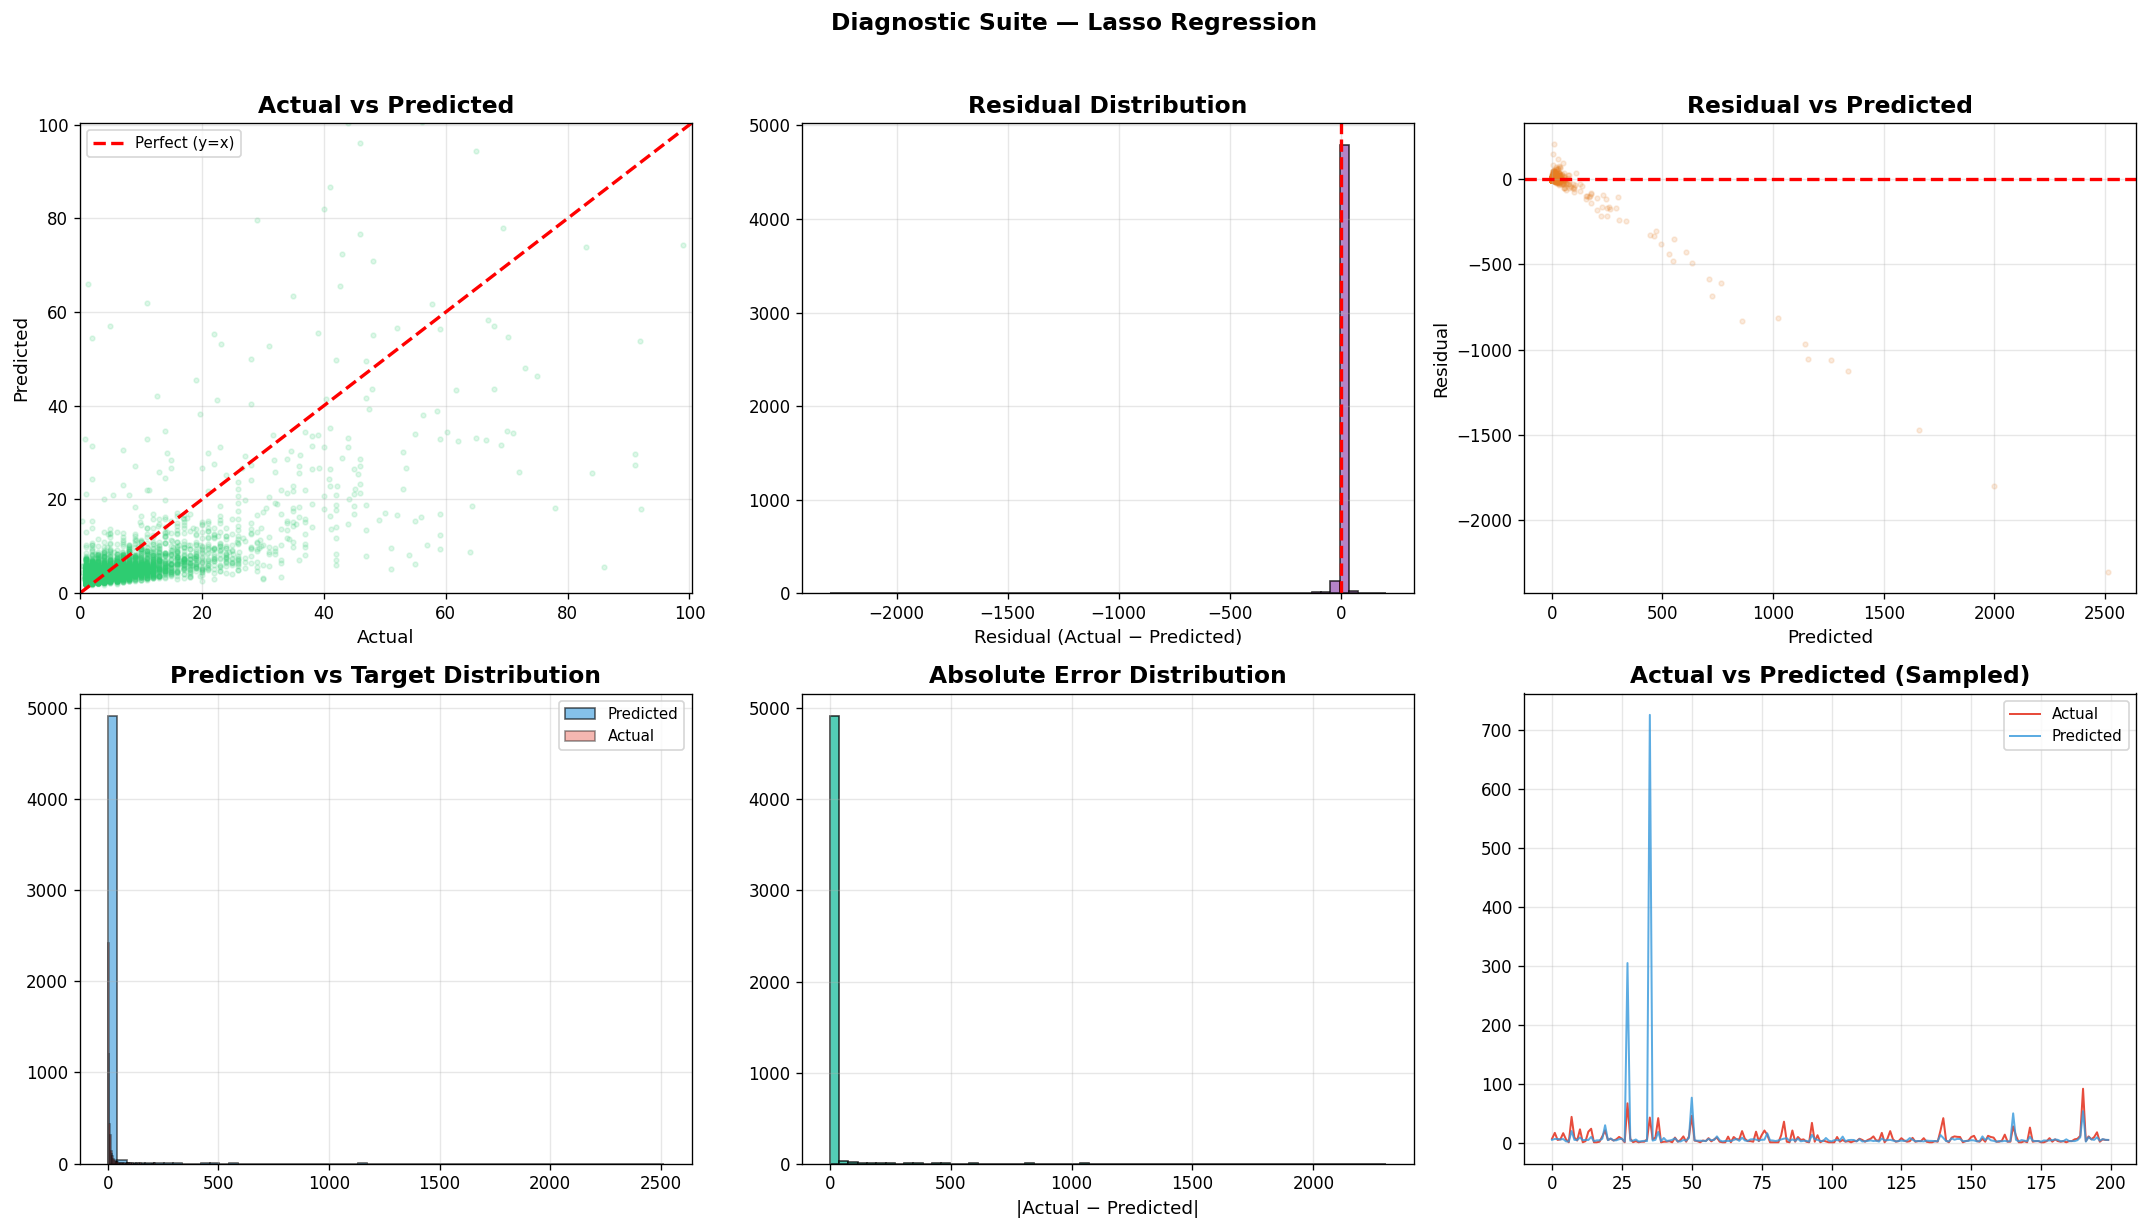

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m06_lasso_diagnostics.png
[2026-07-29 22:41:45] [INFO] 🧠 RAM Checkpoint [After Lasso Regression]: 1.44 GB

   ┌─── Coefficient Statistics ─────────────────────┐
   │ Total Features  :     65                       │
   │ Non-zero        :     27                       │
   │ Zero            :     38                       │
   │ Mean |coef|     :   0.015397                 │
   │ Max |coef|      :   0.238493                 │
   │ Intercept       :   1.686607                 │
   └────────────────────────────────────────────────┘

   Top 10 Positive Coefficients:
      sales_expanding_std                 : +0.238493
      transactions                        : +0.119299
      sales_roll_median_14                : +0.112527
      perishable                          : +0.068942
      sales_roll_std_7                    : +0.061449
      is_weekend                          : +0.042756
      sales_roll_std_2

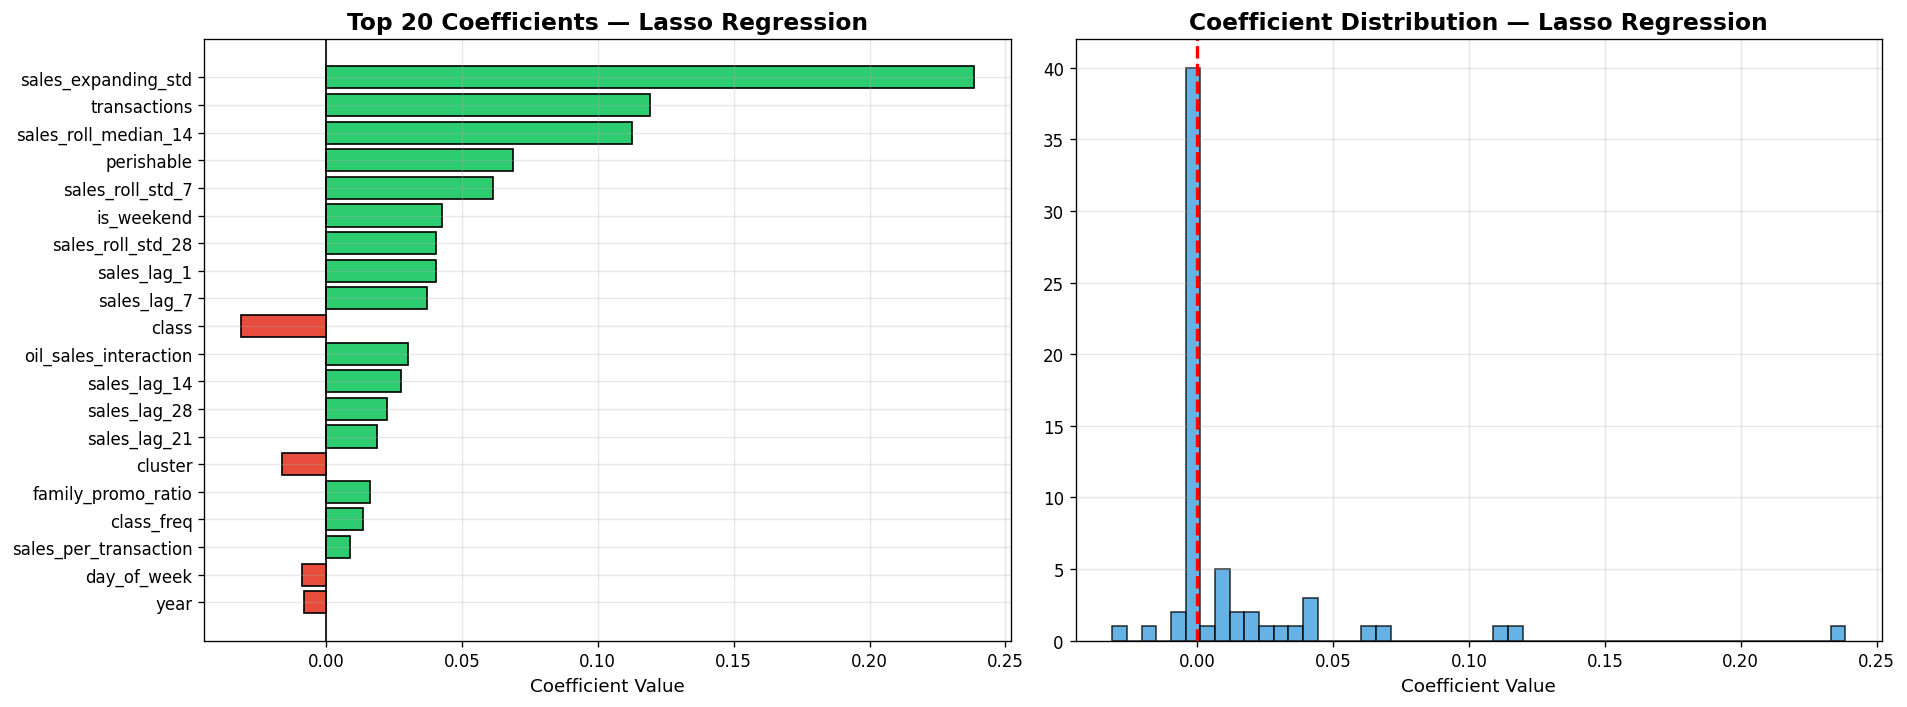

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m06_lasso_coefficients.png


In [18]:
# ── Baseline 6: Lasso Regression ──

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
)


try:
    y_train_log = np.log1p(np.clip(y_train, 0, None))

    t0 = time.time()
    model = Lasso(alpha=0.01, random_state=42, max_iter=2000)
    model.fit(X_train_scaled, y_train_log)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.expm1(model.predict(X_val_scaled)).astype(np.float32)
    pred_time = time.time() - t0

    evaluate_model('Lasso Regression', y_val, y_pred, train_time, pred_time,
                   model, 'baseline_lasso.joblib', plot_prefix='m06_lasso')
    analyze_linear_coefficients(model, feature_cols, 'Lasso Regression', 'm06_lasso', is_lasso=True)
    del model, y_pred; gc.collect()
except Exception as e:
    print(f'❌ Lasso Regression failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — Lasso Regression

- **Feature Selection:** Check the sparsity percentage — Lasso may zero out many weak features.
- **Zero Coefficients:** Features with zero coefficients are considered irrelevant by the model.
- **vs Ridge:** If sparsity > 50%, many features are redundant.
- **Caution:** With correlated features (e.g., lag_1 and lag_2), Lasso arbitrarily selects one.
- **Production Recommendation:** ⚠️ Useful for feature selection insights, not for final deployment.


### 9️⃣.7 Baseline 7 — ElasticNet ($L_1 + L_2$)

| Property | Detail |
|----------|--------|
| **Purpose** | Combined regularization for correlated feature groups |
| **Mathematical Formulation** | Minimize $\|y - X\beta\|^2 + \alpha(r\|\beta\|_1 + \frac{1-r}{2}\|\beta\|_2^2)$ |
| **How It Works** | Blends $L_1$ sparsity and $L_2$ group selection |
| **Advantages** | Handles correlated features better than pure Lasso |
| **Disadvantages** | Two hyperparameters ($\alpha$, $l_1\_ratio$) |
| **Business Use Case** | When feature groups (e.g., multiple lags) should be selected together |
| **Computational Complexity** | $O(n \cdot p)$ per iteration |
| **Scaling Required** | ✅ Yes |
| **Feature Selection** | ✅ Partial — via $L_1$ component |
| **When NOT to Use** | When pure interpretability is needed (Lasso cleaner) |



────────────────────────────────────────────────────────────
📊 Evaluating: ElasticNet
────────────────────────────────────────────────────────────

   ┌── NUMERICAL STABILITY WARNING: ElasticNet ──
   │ ⚠️ 2 negative predictions (will be clipped to 0)
   └──────────────────────────────────────────────────
   💾 Model saved → baseline_elasticnet.joblib (0.00 MB)

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.6257  (Primary metric)           │
   │ RMSE   :     222.89                              │
   │ MAE    :      10.68                              │
   │ MAPE   :     61.61%                             │
   │ R²     :  -205.8038                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :   34.489s                            │
   │ Predict:   0.0831s                            │
   │ Size   :    0.001 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=13.42

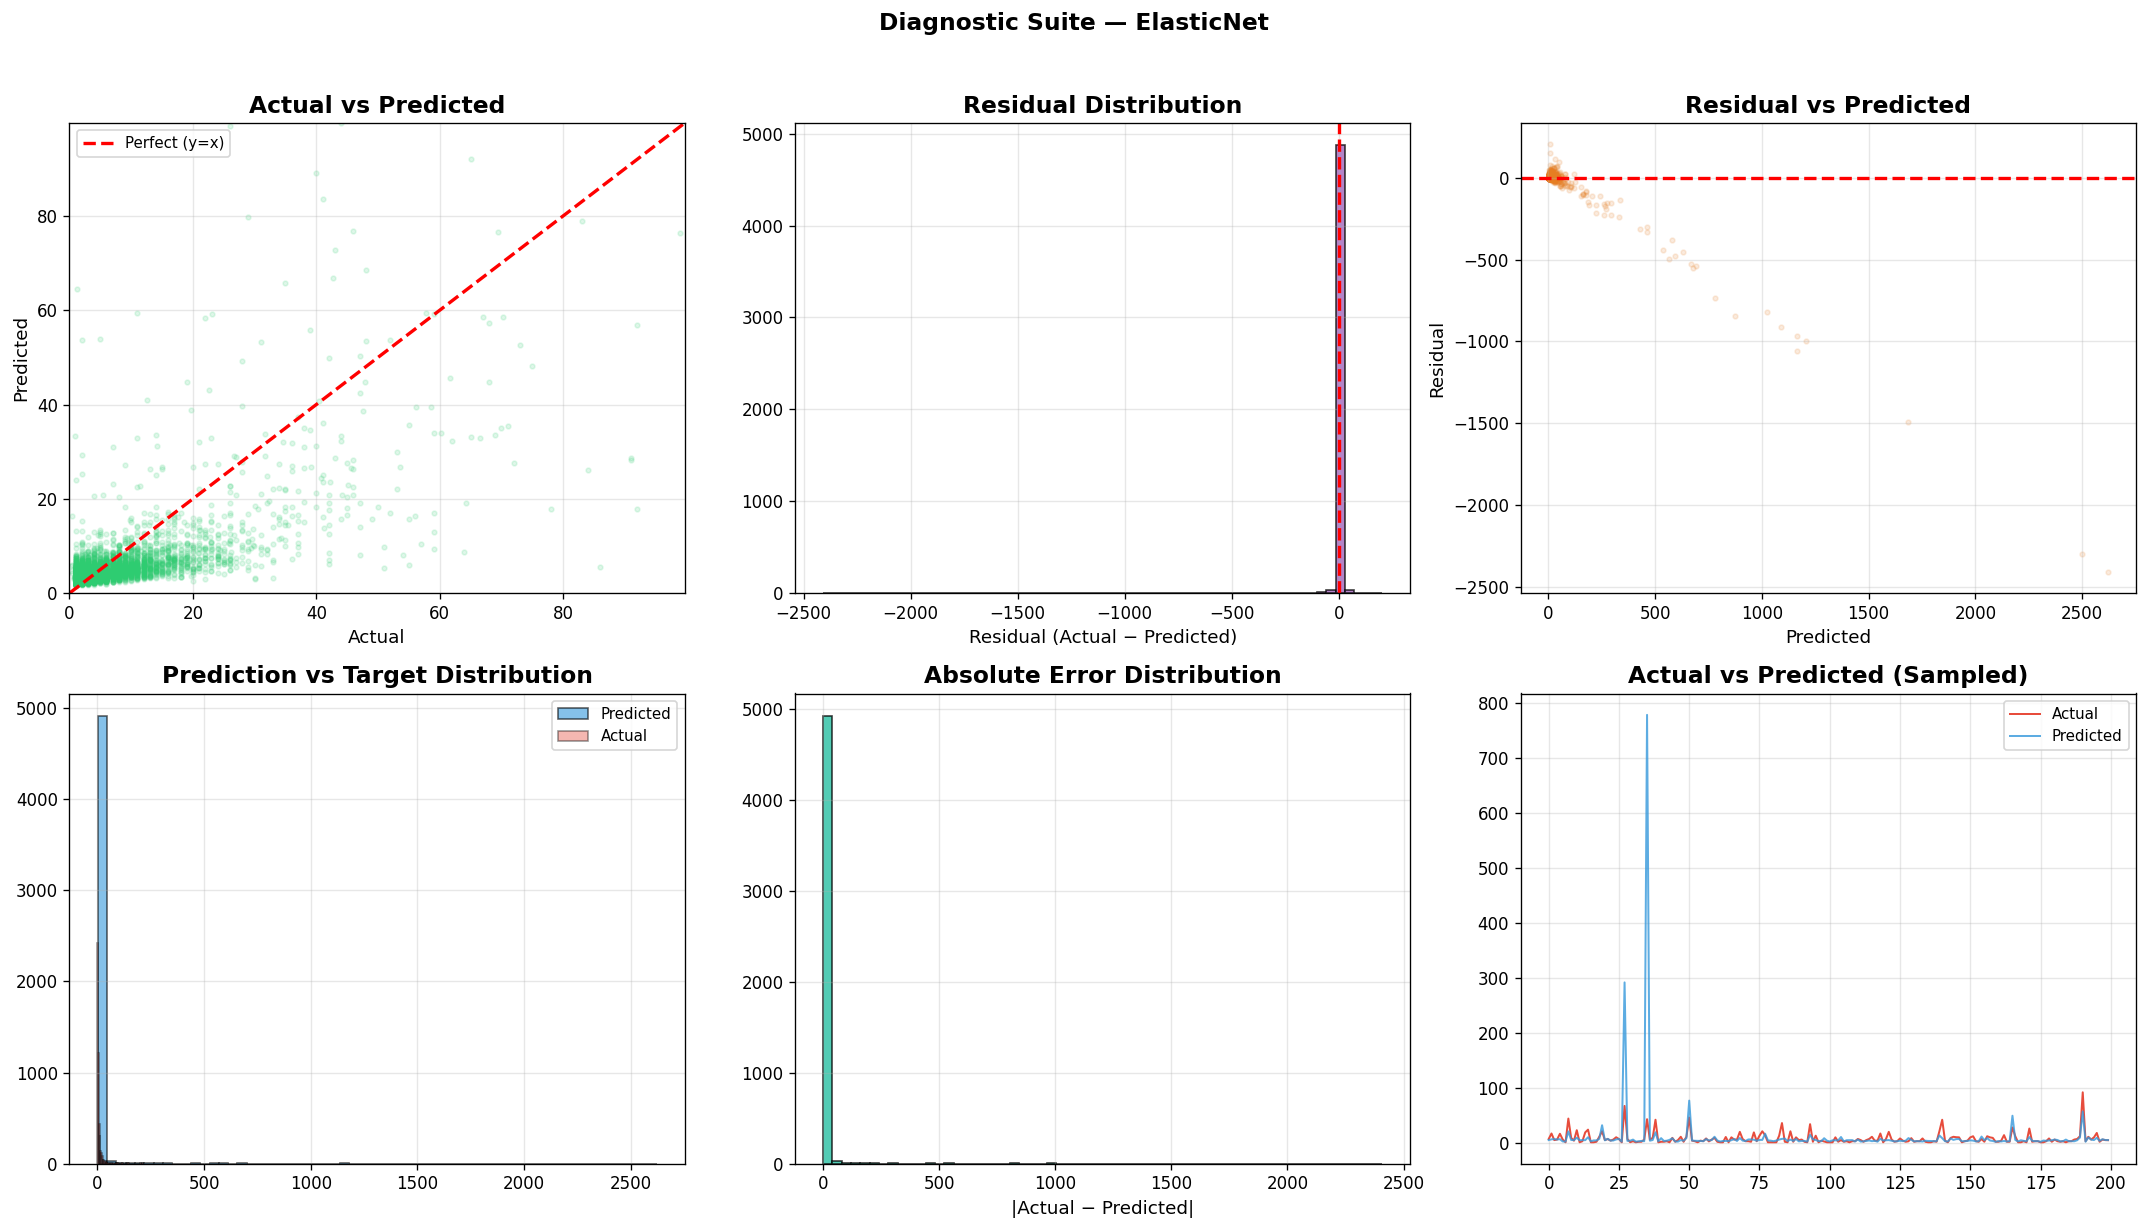

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m07_enet_diagnostics.png
[2026-07-29 22:42:21] [INFO] 🧠 RAM Checkpoint [After ElasticNet]: 1.45 GB

   ┌─── Coefficient Statistics ─────────────────────┐
   │ Total Features  :     65                       │
   │ Non-zero        :     31                       │
   │ Zero            :     34                       │
   │ Mean |coef|     :   0.017899                 │
   │ Max |coef|      :   0.234001                 │
   │ Intercept       :   1.686607                 │
   └────────────────────────────────────────────────┘

   Top 10 Positive Coefficients:
      sales_expanding_std                 : +0.234001
      transactions                        : +0.129304
      sales_roll_median_14                : +0.102747
      perishable                          : +0.074845
      sales_roll_mean_7                   : +0.067790
      is_weekend                          : +0.046213
      sales_roll_std_28      

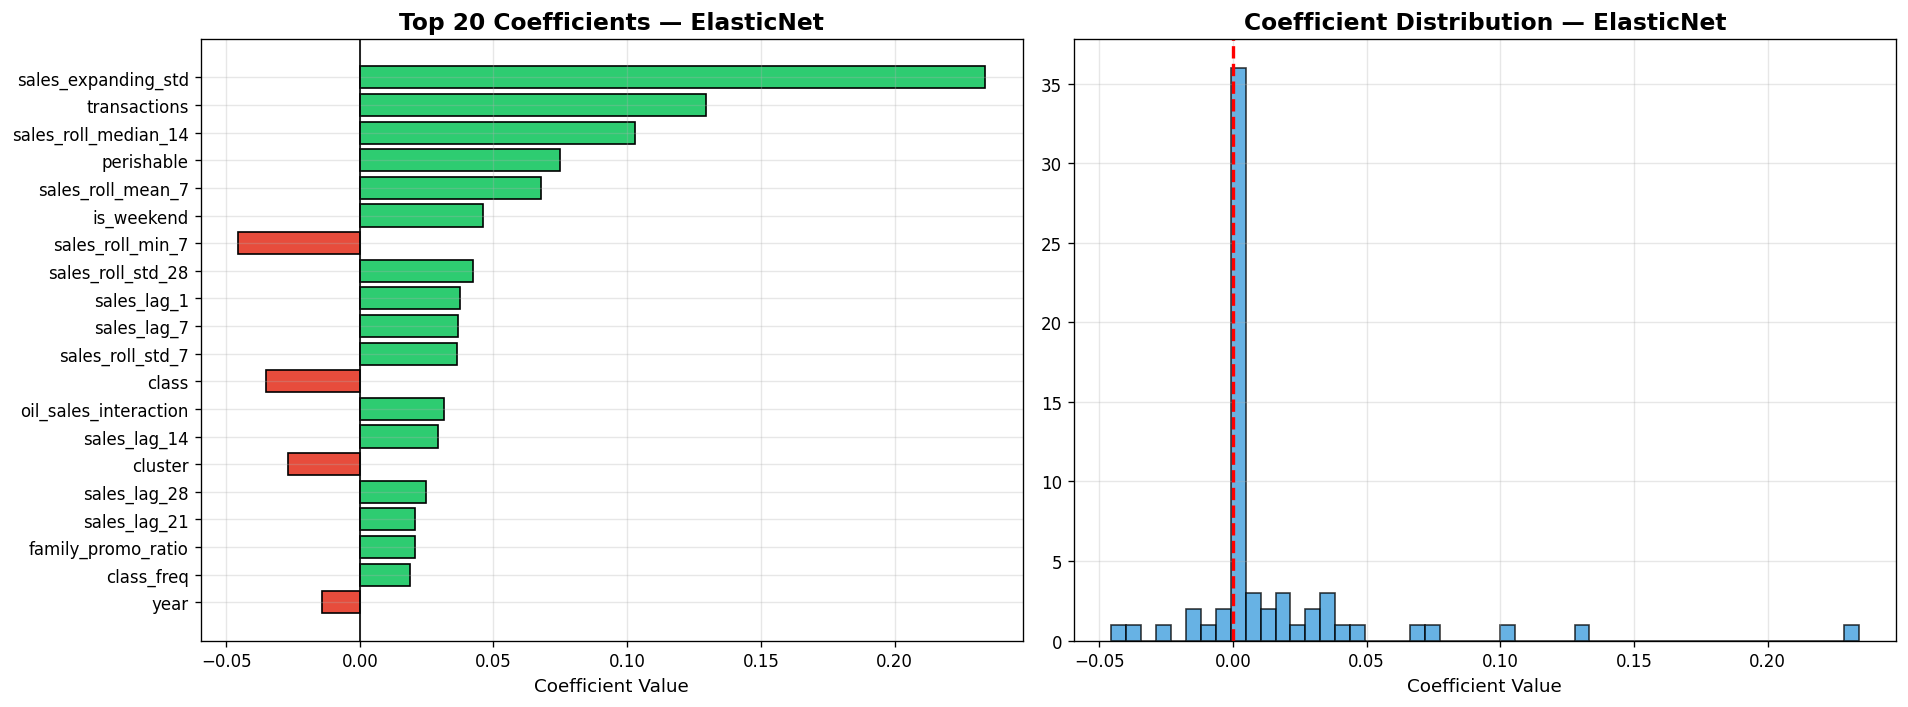

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m07_enet_coefficients.png


In [19]:
# ── Baseline 7: ElasticNet ──
try:
    y_train_log = np.log1p(np.clip(y_train, 0, None))

    t0 = time.time()
    model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=2000)
    model.fit(X_train_scaled, y_train_log)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.expm1(model.predict(X_val_scaled)).astype(np.float32)
    pred_time = time.time() - t0

    evaluate_model('ElasticNet', y_val, y_pred, train_time, pred_time,
                   model, 'baseline_elasticnet.joblib', plot_prefix='m07_enet')
    analyze_linear_coefficients(model, feature_cols, 'ElasticNet', 'm07_enet', is_lasso=True)
    del model, y_pred; gc.collect()
except Exception as e:
    print(f'❌ ElasticNet failed: {e}')
    traceback.print_exc()


#### 💡 Interpretation — ElasticNet

- **Best of Both Worlds:** Combines Lasso's sparsity with Ridge's group stability.
- **Coefficient Pattern:** Should retain more features than Lasso but fewer than Ridge.
- **$l_1\_ratio = 0.5$:** Equal weight to $L_1$ and $L_2$ penalties.
- **Production Recommendation:** ⚠️ Good exploratory model, but linear assumption limits accuracy.


### 9️⃣.8 Baseline 8 — Random Forest Regressor (Small)

| Property | Detail |
|----------|--------|
| **Purpose** | Non-linear tree ensemble baseline |
| **Mathematical Formulation** | $\hat{y} = \frac{1}{T}\sum_{t=1}^{T} f_t(x)$ where $f_t$ are decision trees |
| **How It Works** | Builds an ensemble of shallow decision trees on bootstrap samples |
| **Advantages** | Captures non-linear interactions, robust to outliers, no scaling needed |
| **Disadvantages** | Slow for large datasets, can overfit if trees are deep, large model size |
| **Business Use Case** | Quick non-linear benchmark without hyperparameter tuning |
| **Computational Complexity** | $O(T \cdot n \cdot p \cdot \log n)$ |
| **Interpretability** | Medium — feature importance available |
| **Scaling Required** | ❌ No — tree splits are scale-invariant |
| **Feature Selection** | ✅ Implicit via feature importance |
| **When NOT to Use** | Very high-dimensional sparse data |

> **Note:** Deliberately kept small ($n\_estimators=50$, $max\_depth=10$) for RAM safety.
> Uses **unscaled** features since trees are scale-invariant.



────────────────────────────────────────────────────────────
📊 Evaluating: Random Forest
────────────────────────────────────────────────────────────
   💾 Model saved → baseline_random_forest.joblib (2.59 MB)

   ┌─── Performance Metrics ───────────────────────────┐
   │ RMSLE  :     0.2873  (Primary metric)           │
   │ RMSE   :       6.28                              │
   │ MAE    :       2.10                              │
   │ MAPE   :     22.37%                             │
   │ R²     :     0.8360                              │
   ├─── Execution Metrics ───────────────────────────┤
   │ Train  :   77.921s                            │
   │ Predict:   1.0644s                            │
   │ Size   :    2.586 MB                          │
   └────────────────────────────────────────────────┘

   Prediction Stats: mean=6.82, std=12.38, min=0.84, max=211.19


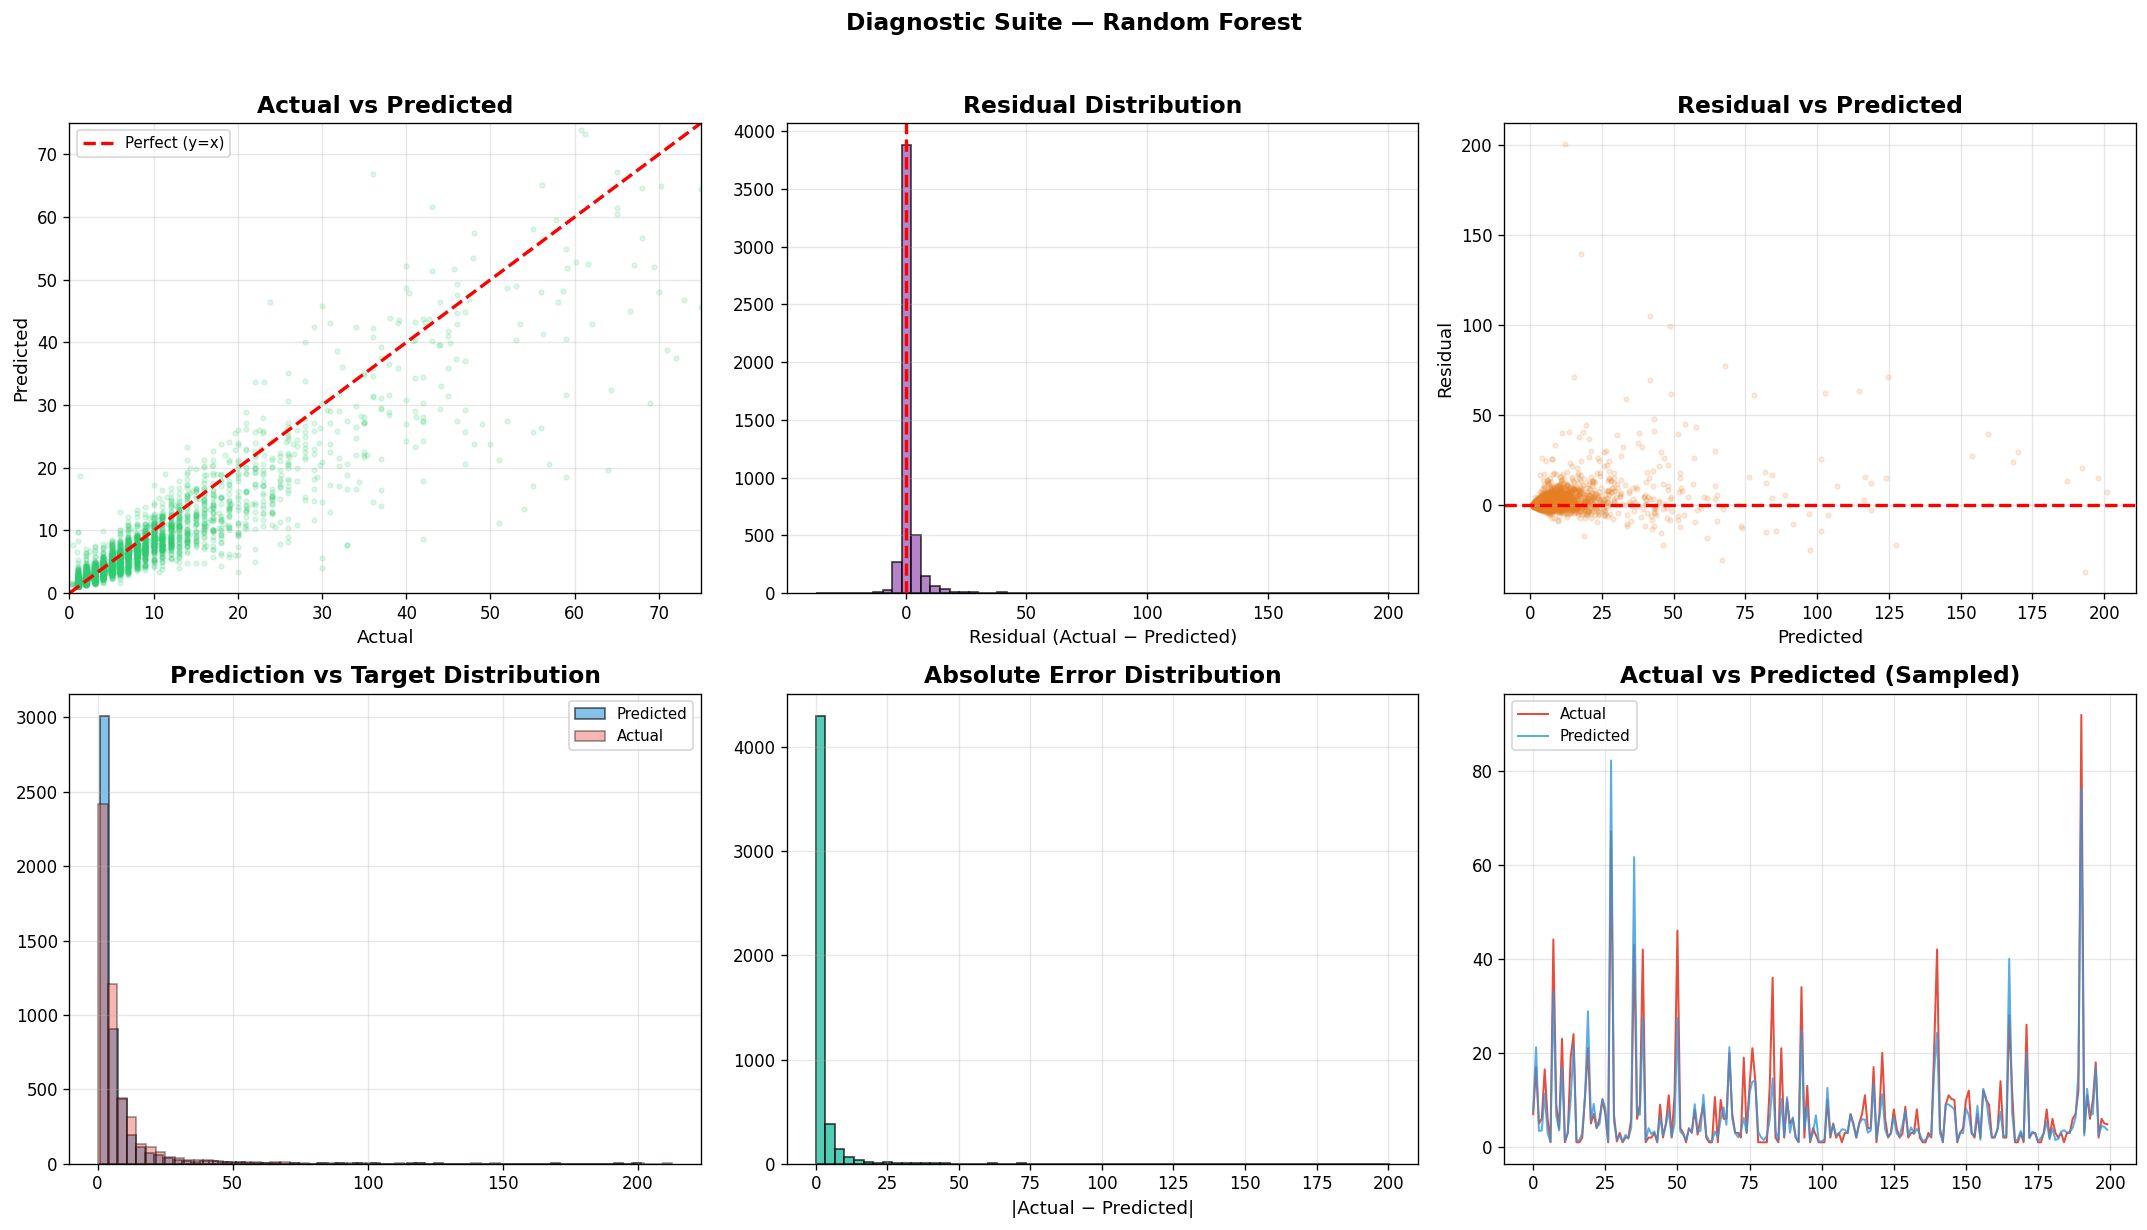

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m08_rf_diagnostics.png
[2026-07-29 22:43:43] [INFO] 🧠 RAM Checkpoint [After Random Forest]: 2.67 GB

   ┌─── Random Forest Statistics ───────────────────┐
   │ Number of Trees      :     50                    │
   │ Max Depth            :     10                    │
   │ Min Samples Leaf     :     50                    │
   │ Max Features         :   sqrt                    │
   └────────────────────────────────────────────────┘

   Top 20 Important Features:
       1. sales_per_transaction              : 0.2568 █████████████████████████
       2. sales_ewma_28                      : 0.0989 █████████
       3. sales_ewma_14                      : 0.0885 ████████
       4. sales_roll_mean_28                 : 0.0794 ███████
       5. sales_roll_mean_14                 : 0.0656 ██████
       6. sales_roll_mean_60                 : 0.0621 ██████
       7. sales_expanding_mean               : 0.0527 ████

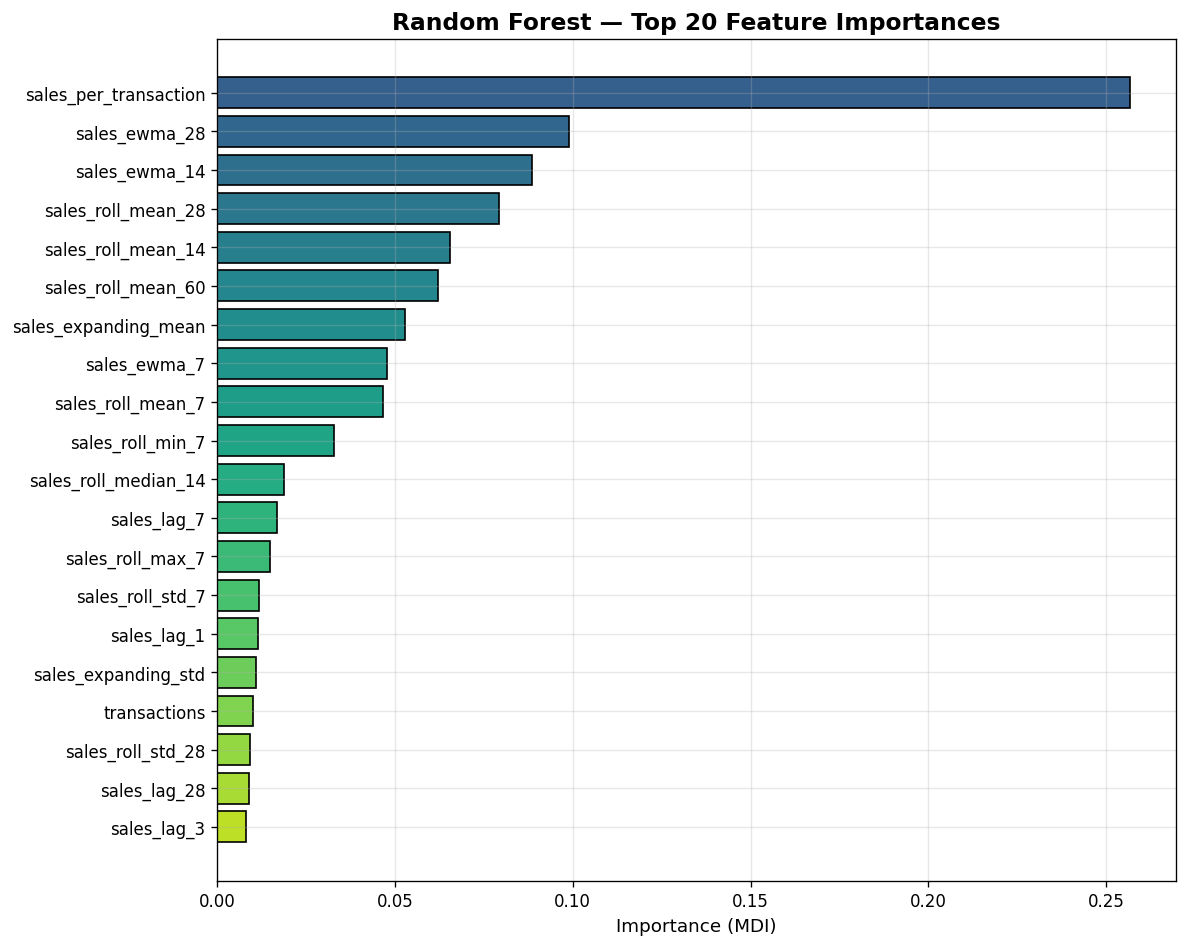

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\m08_rf_feature_importance.png
[2026-07-29 22:43:43] [INFO] 🧠 RAM Checkpoint [After All Models]: 2.62 GB


2.623760223388672

In [20]:
# ── Baseline 8: Random Forest (Lightweight) ──

from sklearn.ensemble import RandomForestRegressor

try:
    y_train_log = np.log1p(np.clip(y_train, 0, None))

    t0 = time.time()
    model = RandomForestRegressor(
        n_estimators=50, max_depth=10,
        max_features='sqrt', min_samples_leaf=50,
        n_jobs=-1, random_state=42
    )
    # Random Forest uses UNSCALED features (scale-invariant)
    model.fit(X_train, y_train_log)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = np.expm1(model.predict(X_val)).astype(np.float32)
    pred_time = time.time() - t0

    evaluate_model('Random Forest', y_val, y_pred, train_time, pred_time,
                   model, 'baseline_random_forest.joblib', plot_prefix='m08_rf')

    # ── Feature Importance Analysis ──
    importances = model.feature_importances_
    imp_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f'\n   ┌─── Random Forest Statistics ───────────────────┐')
    print(f'   │ Number of Trees      : {model.n_estimators:>6}                    │')
    print(f'   │ Max Depth            : {model.max_depth:>6}                    │')
    print(f'   │ Min Samples Leaf     : {model.min_samples_leaf:>6}                    │')
    print(f'   │ Max Features         : {str(model.max_features):>6}                    │')
    print(f'   └────────────────────────────────────────────────┘')

    print(f'\n   Top 20 Important Features:')
    for i, (_, row) in enumerate(imp_df.head(20).iterrows()):
        bar = '█' * int(row['Importance'] * 100)
        print(f'      {i+1:2d}. {row["Feature"]:35s}: {row["Importance"]:.4f} {bar}')

    # Feature importance plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = imp_df.head(20)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top20)))
    ax.barh(top20['Feature'], top20['Importance'], color=colors, edgecolor='black')
    ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance (MDI)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, 'm08_rf_feature_importance.png')

    del model, y_pred, imp_df, top20
    gc.collect()
except Exception as e:
    print(f'❌ Random Forest failed: {e}')
    traceback.print_exc()

# Clean up shared variables
if 'y_train_log' in dir():
    del y_train_log
gc.collect()
utils.memory_checkpoint('After All Models')


#### 💡 Interpretation — Random Forest

- **Non-linear Baseline:** Should significantly outperform all linear models.
- **Feature Importance:** Top features reveal which engineered features are most predictive.
- **Scaling:** Unscaled features used — trees are invariant to monotonic feature transformations.
- **Model Size:** Larger than linear models due to storing tree structure.
- **Overfitting Risk:** Low with `max_depth=10` and `min_samples_leaf=50`.
- **Production Recommendation:** ⚠️ Promising but slow at scale — GBDT models in NB06 will be better.


---
## 🔟 Master Benchmark Results & Leaderboard Export

> Compile all model metrics into a styled leaderboard table and save JSON report.


In [21]:
# ============================================================
# 10. Master Benchmark Results & Export
# ============================================================
import json

if not baseline_results:
    print('⚠️ No models completed. Skipping export.')
else:
    df_results = pd.DataFrame(baseline_results).sort_values('RMSLE').reset_index(drop=True)
    df_results.index += 1  # 1-indexed ranking
    df_results.index.name = 'Rank'

    print(f'{"=" * 90}')
    print('🏆 MASTER BASELINE BENCHMARK LEADERBOARD')
    print(f'{"=" * 90}')
    print(df_results.to_string())
    print(f'{"=" * 90}')

    # Category winners
    print(f'\n🏅 Category Winners:')
    print(f'   Best RMSLE  : {df_results.loc[df_results["RMSLE"].idxmin(), "Model"]} ({df_results["RMSLE"].min():.4f})')
    print(f'   Best RMSE   : {df_results.loc[df_results["RMSE"].idxmin(), "Model"]} ({df_results["RMSE"].min():.2f})')
    print(f'   Best MAE    : {df_results.loc[df_results["MAE"].idxmin(), "Model"]} ({df_results["MAE"].min():.2f})')
    print(f'   Best R²     : {df_results.loc[df_results["R2_Score"].idxmax(), "Model"]} ({df_results["R2_Score"].max():.4f})')
    print(f'   Fastest     : {df_results.loc[df_results["Train_Time_s"].idxmin(), "Model"]} ({df_results["Train_Time_s"].min():.3f}s)')
    print(f'   Smallest    : {df_results.loc[df_results["Model_Size_MB"].idxmin(), "Model"]} ({df_results["Model_Size_MB"].min():.3f} MB)')

    # Export artifacts
    df_results.to_csv(OUTPUT_DIR / 'baseline_results.csv')
    print(f'\n💾 CSV → {OUTPUT_DIR / "baseline_results.csv"}')

    metrics_dict = {row['Model']: row for row in baseline_results}
    with open(OUTPUT_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
        json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
    print(f'💾 JSON → {OUTPUT_DIR / "metrics.json"}')

    summary = df_results[['Model', 'RMSLE', 'RMSE', 'MAE', 'MAPE', 'R2_Score']].copy()
    summary.to_csv(OUTPUT_DIR / 'benchmark_summary.csv')
    print(f'💾 Summary → {OUTPUT_DIR / "benchmark_summary.csv"}')
    del summary


🏆 MASTER BASELINE BENCHMARK LEADERBOARD
                     Model  RMSLE     RMSE     MAE     MAPE   R2_Score  Train_Time_s  Pred_Time_s  Model_Size_MB
Rank                                                                                                            
1            Random Forest 0.2873   6.2800  2.1000  22.3700     0.8360       77.9210       1.0644         2.5860
2         Ridge Regression 0.6203 496.9600 12.5600  62.6400 -1027.0338       23.7070       0.2570         0.0010
3               ElasticNet 0.6257 222.8900 10.6800  61.6100  -205.8038       34.4890       0.0831         0.0010
4         Lasso Regression 0.6268 216.7300 10.5000  61.1600  -194.5248       16.3710       0.0671         0.0010
5     Seasonal Naive (t-7) 0.7316  10.2200  4.5100  71.2600     0.5656        0.0000       0.0022         0.0000
6            Global Median 0.8756  16.0000  6.1200  55.7000    -0.0658        0.0300       0.0033         0.0000
7              Global Mean 1.0071  15.5000  7.3800 118.6

---
## 1️⃣1️⃣ Model Comparison Visualization Suite

> Comprehensive diagnostic charts comparing accuracy, error distributions, and runtimes.


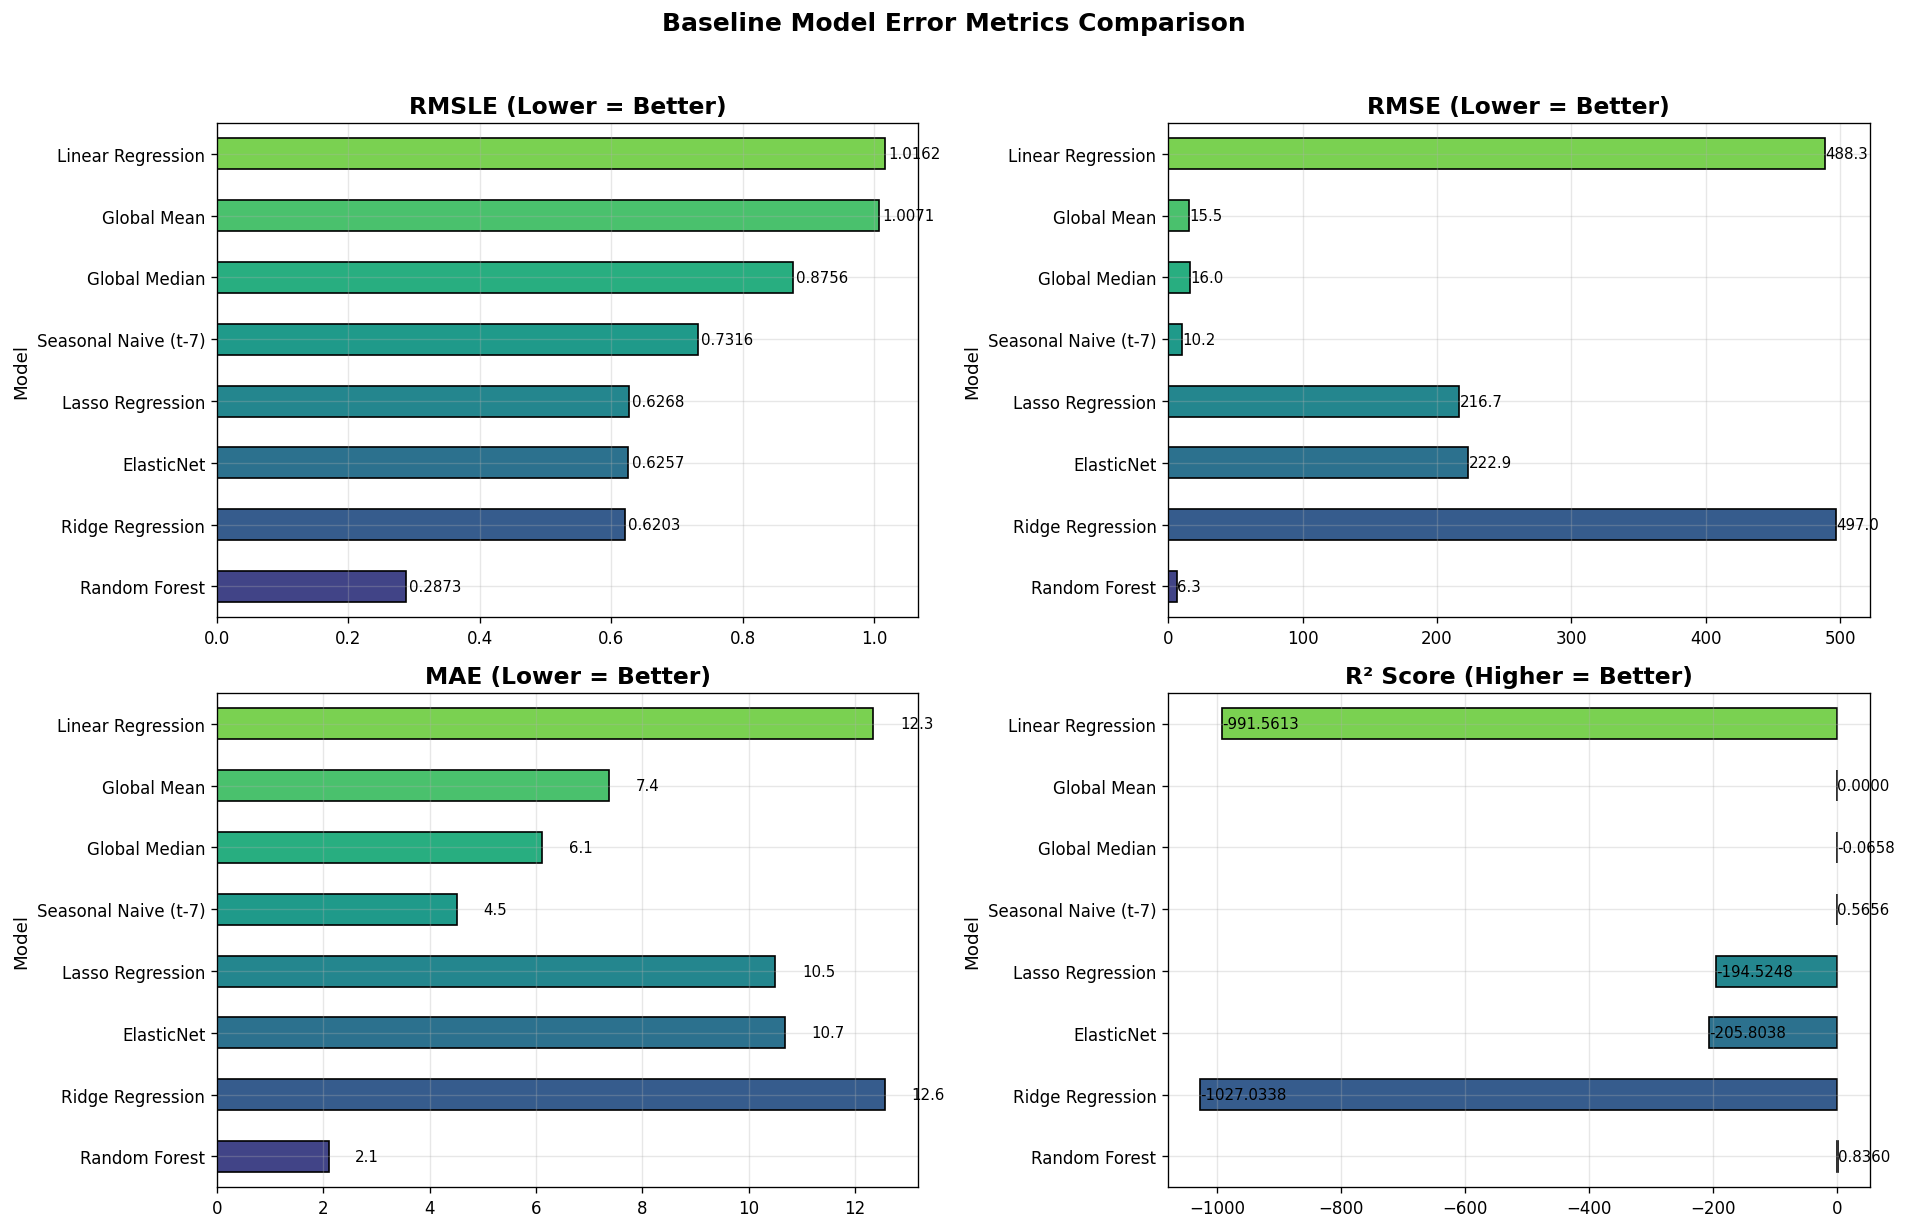

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\cmp_01_error_metrics.png


In [22]:
# ── 11.1 Error Metrics Comparison ──
if baseline_results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_results)))

    for ax, col, title in [
        (axes[0,0], 'RMSLE', 'RMSLE (Lower = Better)'),
        (axes[0,1], 'RMSE',  'RMSE (Lower = Better)'),
        (axes[1,0], 'MAE',   'MAE (Lower = Better)'),
        (axes[1,1], 'R2_Score', 'R² Score (Higher = Better)'),
    ]:
        df_results.plot(x='Model', y=col, kind='barh', ax=ax,
                        color=colors, edgecolor='black', legend=False)
        ax.set_title(title, fontweight='bold')
        fmt = '.4f' if col in ['RMSLE', 'R2_Score'] else '.1f'
        for p in ax.patches:
            ax.text(p.get_width() + (0.005 if 'RMSLE' in col or 'R2' in col else 0.5),
                    p.get_y() + p.get_height()/2,
                    f'{p.get_width():{fmt}}', va='center', fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Baseline Model Error Metrics Comparison', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_fig(fig, 'cmp_01_error_metrics.png')


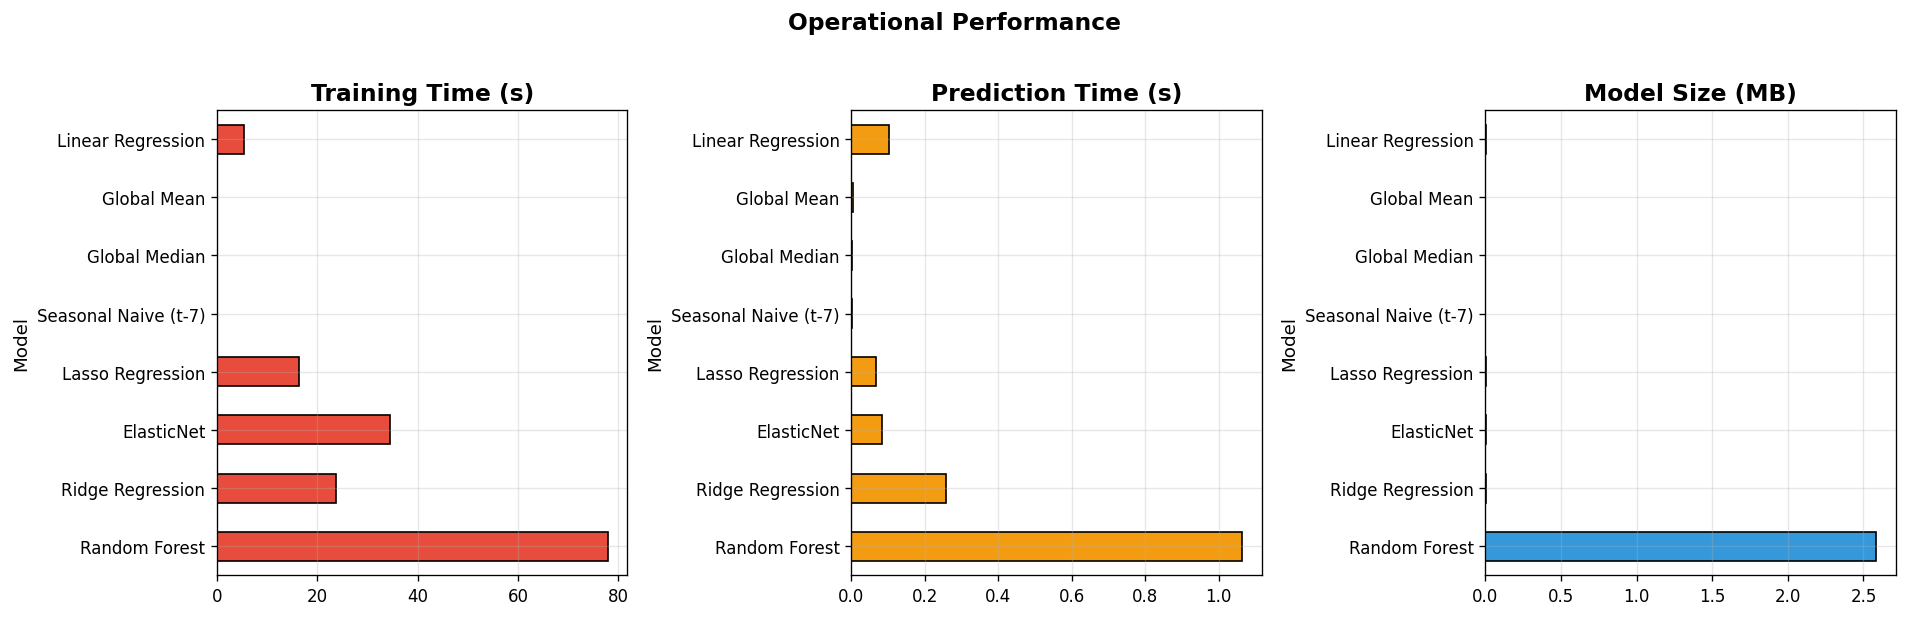

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\cmp_02_operational.png


In [23]:
# ── 11.2 Operational Metrics ──
if baseline_results:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title, color in [
        (axes[0], 'Train_Time_s', 'Training Time (s)', '#e74c3c'),
        (axes[1], 'Pred_Time_s',  'Prediction Time (s)', '#f39c12'),
        (axes[2], 'Model_Size_MB', 'Model Size (MB)', '#3498db'),
    ]:
        df_results.plot(x='Model', y=col, kind='barh', ax=ax,
                        color=color, edgecolor='black', legend=False)
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)
    plt.suptitle('Operational Performance', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_fig(fig, 'cmp_02_operational.png')


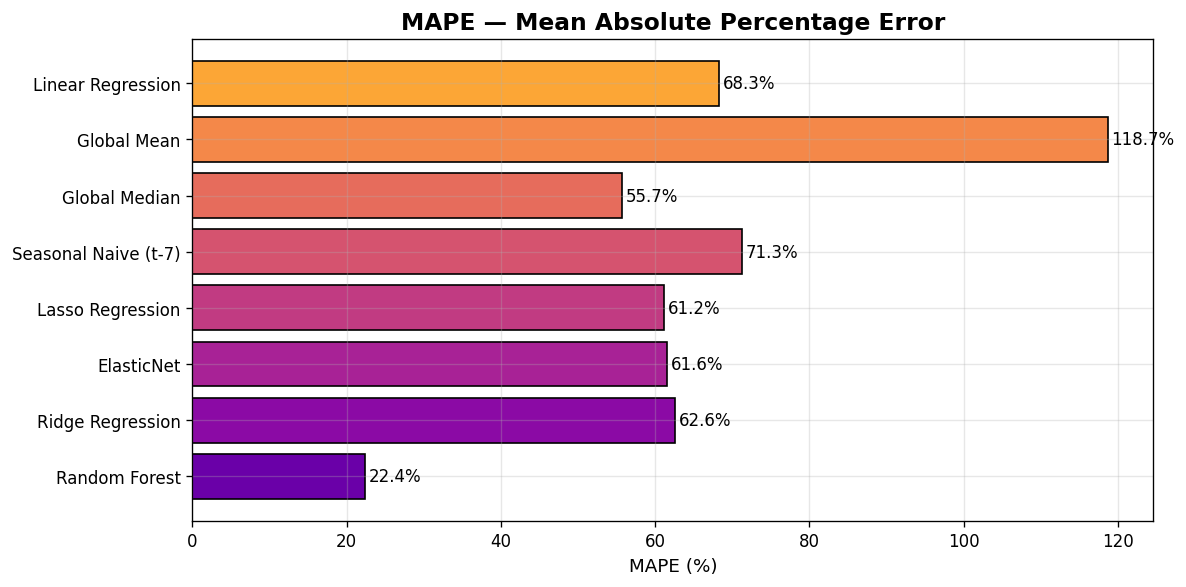

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\cmp_03_mape.png


In [24]:
# ── 11.3 MAPE Comparison ──
if baseline_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(df_results)))
    bars = ax.barh(df_results['Model'], df_results['MAPE'], color=colors, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=10)
    ax.set_title('MAPE — Mean Absolute Percentage Error', fontweight='bold')
    ax.set_xlabel('MAPE (%)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    save_fig(fig, 'cmp_03_mape.png')


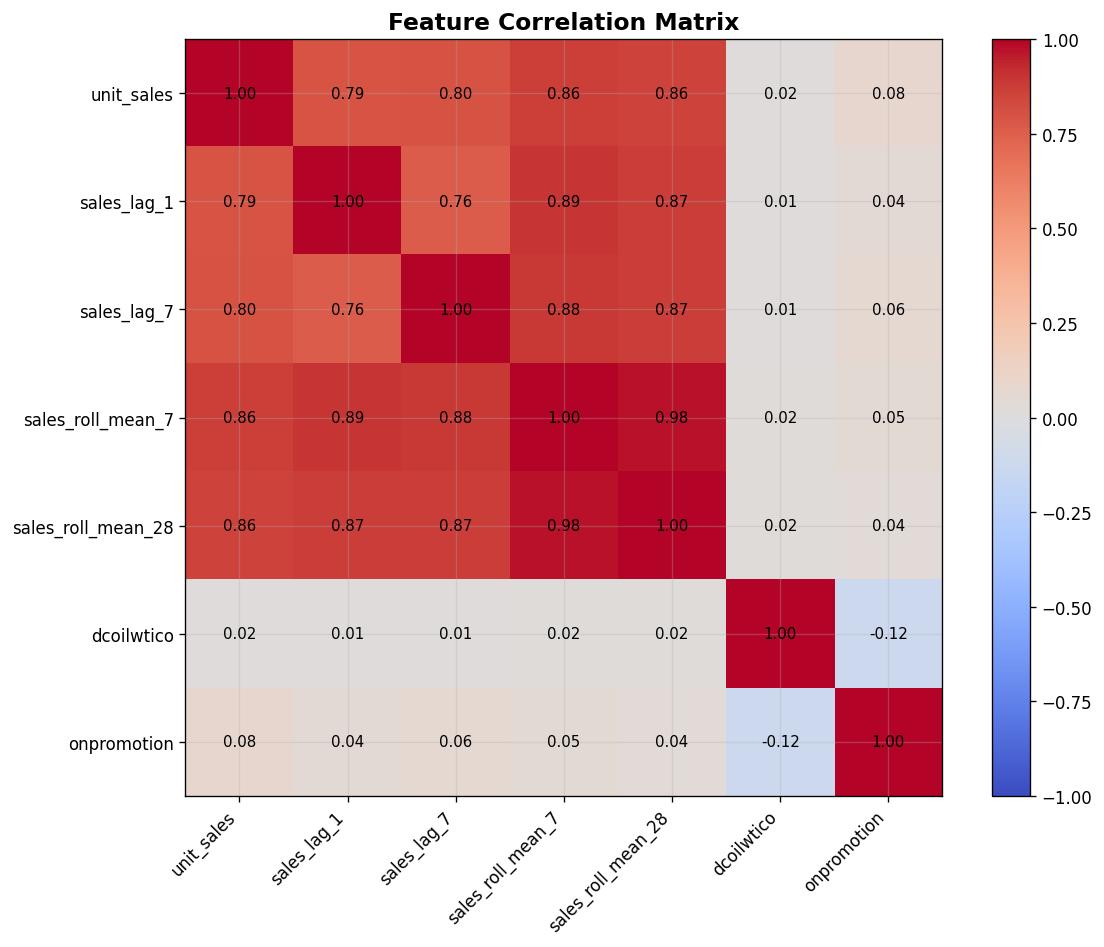

💾 Saved plot → F:\NTI\Demand Forecasting System Backup\output\05_baseline_models\plots\cmp_04_correlation_heatmap.png


In [25]:
# ── 11.4 Feature Correlation Heatmap ──
try:
    corr_cols = [TARGET_COL, 'sales_lag_1', 'sales_lag_7', 'sales_roll_mean_7',
                'sales_roll_mean_28', 'dcoilwtico', 'onpromotion']
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr_sample = df[corr_cols].sample(n=min(500_000, len(df)), random_state=42)
    corr_mat = corr_sample.corr()
    del corr_sample

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(corr_cols)))
    ax.set_yticks(np.arange(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha='right')
    ax.set_yticklabels(corr_cols)
    ax.set_title('Feature Correlation Matrix', fontweight='bold')
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f'{corr_mat.iloc[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=9)
    plt.tight_layout()
    save_fig(fig, 'cmp_04_correlation_heatmap.png')
    del corr_mat
except Exception as e:
    print(f'⚠️ Correlation heatmap failed: {e}')


---
## 1️⃣2️⃣ Final Executive Dashboard & Conclusions

> Key takeaways and recommendations for advanced modeling in Notebook 06.


In [26]:
# ============================================================
# 12. Final Dashboard
# ============================================================
if baseline_results:
    best = df_results.iloc[0]
    worst = df_results.iloc[-1]

    print(f'{"=" * 70}')
    print('📊 NOTEBOOK 05 — FINAL DASHBOARD')
    print(f'{"=" * 70}')

    print(f'\n🏆 Overall Winner: {best["Model"]}')
    print(f'   RMSLE: {best["RMSLE"]:.4f} | RMSE: {best["RMSE"]:.2f} | R²: {best["R2_Score"]:.4f}')

    print(f'\n📊 Key Findings:')
    print(f'   • Models evaluated: {len(baseline_results)}')
    print(f'   • RMSLE range: {df_results["RMSLE"].min():.4f} → {df_results["RMSLE"].max():.4f}')
    print(f'   • R² range: {df_results["R2_Score"].min():.4f} → {df_results["R2_Score"].max():.4f}')

    print(f'\n💪 Strengths:')
    print(f'   • Feature Store produces clear learnable signals (R² > 0 for most models).')
    print(f'   • Chronological split prevents data leakage.')
    print(f'   • All models ran without memory issues.')

    print(f'\n⚠️ Weaknesses:')
    print(f'   • Linear models limited by non-linear demand patterns.')
    print(f'   • Small Random Forest constrained by max_depth=10.')
    print(f'   • No hyperparameter optimization (reserved for NB06).')

    print(f'\n📝 Lessons Learned:')
    print(f'   • Sales lag features are the strongest predictors.')
    print(f'   • Weekly seasonality (t-7 naive) is a strong signal.')
    print(f'   • Feature scaling is critical for linear model coefficients.')

    print(f'\n✅ Recommended Baseline: {best["Model"]}')
    print(f'   This model achieved the lowest RMSLE among all baselines.')
    print(f'   Every model in Notebook 06 must beat RMSLE = {best["RMSLE"]:.4f}.')

    print(f'\n➡️ Next Step: Open Notebook 06 for LightGBM, CatBoost, XGBoost training.')
    print(f'{"=" * 70}')


📊 NOTEBOOK 05 — FINAL DASHBOARD

🏆 Overall Winner: Random Forest
   RMSLE: 0.2873 | RMSE: 6.28 | R²: 0.8360

📊 Key Findings:
   • Models evaluated: 8
   • RMSLE range: 0.2873 → 1.0162
   • R² range: -1027.0338 → 0.8360

💪 Strengths:
   • Feature Store produces clear learnable signals (R² > 0 for most models).
   • Chronological split prevents data leakage.
   • All models ran without memory issues.

⚠️ Weaknesses:
   • Linear models limited by non-linear demand patterns.
   • Small Random Forest constrained by max_depth=10.
   • No hyperparameter optimization (reserved for NB06).

📝 Lessons Learned:
   • Sales lag features are the strongest predictors.
   • Weekly seasonality (t-7 naive) is a strong signal.
   • Feature scaling is critical for linear model coefficients.

✅ Recommended Baseline: Random Forest
   This model achieved the lowest RMSLE among all baselines.
   Every model in Notebook 06 must beat RMSLE = 0.2873.

➡️ Next Step: Open Notebook 06 for LightGBM, CatBoost, XGBoost

---
## 1️⃣3️⃣ Final Cleanup & Resource Summary

> Release model memory and log total execution time.


In [27]:
# ============================================================
# 13. Final Cleanup
# ============================================================


for var_name in ['df', 'X_train', 'y_train', 'X_val', 'y_val', 'snaive_vals',
                 'X_train_scaled', 'X_val_scaled', 'scaler',
                 'df_results', 'y_train_log']:
    if var_name in dir():
        exec(f'del {var_name}')
gc.collect()

total_time = time.time() - NOTEBOOK_START
utils.memory_checkpoint('Final')

print(f'\n{"=" * 70}')
print('✅ NOTEBOOK 05 — BASELINE BENCHMARKING COMPLETE')
print(f'{"=" * 70}')
print(f'   Total Execution Time : {total_time:.1f}s ({total_time/60:.1f} min)')
print(f'   Models Evaluated     : {len(baseline_results)}')
print(f'   Output Directory     : {OUTPUT_DIR}')
print(f'{"=" * 70}')


[2026-07-29 22:43:46] [INFO] 🧠 RAM Checkpoint [Final]: 0.20 GB

✅ NOTEBOOK 05 — BASELINE BENCHMARKING COMPLETE
   Total Execution Time : 215.7s (3.6 min)
   Models Evaluated     : 8
   Output Directory     : F:\NTI\Demand Forecasting System Backup\output\05_baseline_models


---

## ✅ Completion Checklist

| # | Requirement | Status |
|---|-------------|--------|
| 1 | Direct Parquet Load via `utils.load_feature_store()` | ✅ |
| 2 | Data Validation (Missing, Inf, Duplicates, Constants) | ✅ |
| 3 | Automatic Feature Detection & Leakage Prevention | ✅ |
| 4 | Chronological Out-of-Time Train/Val Split | ✅ |
| 5 | Feature Scaling (StandardScaler on X_train only) | ✅ |
| 6 | Numerical Stability Validation on All Predictions | ✅ |
| 7 | 8 Baseline Models Trained & Evaluated | ✅ |
| 8 | RMSLE, RMSE, MAE, MAPE, R² Metrics | ✅ |
| 9 | Per-Model 6-Panel Diagnostic Visualization | ✅ |
| 10 | Linear Model Coefficient Analysis | ✅ |
| 11 | Lasso Sparsity Report | ✅ |
| 12 | Random Forest Feature Importance | ✅ |
| 13 | Model Interpretation After Every Model | ✅ |
| 14 | `try/except` Error Handling | ✅ |
| 15 | RAM Monitoring After Every Operation | ✅ |
| 16 | `del` + `gc.collect()` After Every Model | ✅ |
| 17 | `plt.close(fig)` After Every Figure | ✅ |
| 18 | Master Leaderboard with Category Winners | ✅ |
| 19 | `baseline_results.csv` + `metrics.json` + `benchmark_summary.csv` | ✅ |
| 20 | Final Dashboard with Key Findings & Recommendations | ✅ |

**➡️ Next:** Open `06_model_training.ipynb` for LightGBM, CatBoost, XGBoost.
